In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import hvplot.pandas
import seaborn as sns
import requests

np.random.seed(42)

In [2]:
pd.options.display.max_columns = 999

# Lecture 13B: Predictive modeling with scikit-learn, continued

## Picking up where we left off

We'll start by recapping the exercise from last lecture: adding additional distance-based features to our housing price model...

## Spatial amenity/disamenity features

**The strategy**

- Get the data for a certain type of amenity, e.g., restaurants, bars, or disamenity, e.g., crimes
    - Data sources: 311 requests, crime incidents, Open Street Map
- Use scikit learn's nearest neighbor algorithm to calculate the distance from each sale to its nearest neighbor in the amenity/disamenity datasets

## Examples of new possible features...

Distance from each sale to:

- **Graffiti 311 Calls (last lecture)**
- **Subway Stops (last lecture)**
- Universities
- Parks
- City Hall
- New Construction Permits
- Aggravated Assaults
- Abandoned Vehicle 311 Calls

In [3]:
# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Pipelines
from sklearn.pipeline import make_pipeline

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder

# Neighbors
from sklearn.neighbors import NearestNeighbors

In [4]:
def get_carto_data(table_name, where=None, limit=None):
    """
    Download data from CARTO given a specific table name and
    optionally a where statement or limit.
    """

    # the CARTO API url
    carto_url = "https://phl.carto.com/api/v2/sql"

    # Create the query
    query = f"SELECT * FROM {table_name}"

    # Add a where
    if where is not None:
        query = query + f" WHERE {where}"

    # Add a limit
    if limit is not None:
        query = query + f" LIMIT {limit}"

    # Make the request
    params = {"q": query, "format": "geojson"}
    response = requests.get(carto_url, params=params)

    # Make the GeoDataFrame
    return gpd.GeoDataFrame.from_features(response.json(), crs="EPSG:4326")

Load and clean the data using the utility function above:

In [6]:
# the CARTO API url
carto_url = "https://phl.carto.com/api/v2/sql"

# The table name
table_name = "opa_properties_public"

# Only pull 2022 sales for single family residential properties
where = "sale_date >= '2022-01-01' AND sale_date < '2023-01-01'" 
where = where + " AND category_code_description IN ('SINGLE FAMILY', 'Single Family')"

# Run the query
salesRaw = get_carto_data(table_name, where=where)

# Optional: put it a reproducible order for test/training splits later
salesRaw = salesRaw.sort_values("parcel_number")

# The feature columns we want to use
cols = [
    "sale_price",
    "total_livable_area",
    "total_area",
    "garage_spaces",
    "fireplaces",
    "number_of_bathrooms",
    "number_of_bedrooms",
    "number_stories",
    "exterior_condition",
    "zip_code",
    "geometry"
]

# Trim to these columns and remove NaNs
sales = salesRaw[cols].dropna()

# Trim zip code to only the first five digits
sales['zip_code'] = sales['zip_code'].astype(str).str.slice(0, 5)

# Trim very low and very high sales
valid = (sales['sale_price'] > 3000) & (sales['sale_price'] < 1e6)
sales = sales.loc[valid]

In [7]:
len(sales)

17390

In [10]:
sales.head()

,sale_price,total_livable_area,total_area,garage_spaces,fireplaces,number_of_bathrooms,number_of_bedrooms,number_stories,exterior_condition,zip_code,geometry
982,450000.0,1785.0,1625.0,1.0,1.0,2.0,3.0,3.0,4,19147,POINT (-75.1486 39.93145)
12359,670000.0,2244.0,1224.0,0.0,0.0,3.0,4.0,3.0,3,19147,POINT (-75.14818 39.93101)
9721,790000.0,2514.0,1400.0,1.0,0.0,4.0,3.0,2.0,3,19147,POINT (-75.1478 39.9301)
3065,195000.0,1358.0,840.0,0.0,0.0,2.0,3.0,3.0,4,19147,POINT (-75.14887 39.93026)
11720,331000.0,868.0,546.0,0.0,0.0,2.0,2.0,2.0,4,19147,POINT (-75.14881 39.93012)


Add new distance-based features:

In [8]:
def get_xy_from_geometry(df):
    """
    Return a numpy array with two columns, where the 
    first holds the `x` geometry coordinate and the second 
    column holds the `y` geometry coordinate
    
    Note: this works with both Point() and Polygon() objects.
    """
    # NEW: use the centroid.x and centroid.y to support Polygon() and Point() geometries 
    x = df.geometry.centroid.x
    y = df.geometry.centroid.y
    
    return np.column_stack((x, y)) # stack as columns

In [11]:
# Convert to meters and EPSG=3857
sales_3857 = sales.to_crs(epsg=3857)

# Extract x/y for sales
salesXY = get_xy_from_geometry(sales_3857)

In [15]:
salesXY.shape, salesXY

((17390, 2),
 array([[-8365504.33110536,  4855986.06521187],
        [-8365456.57504381,  4855922.04472378],
        [-8365415.38683222,  4855789.06924578],
        ...,
        [-8346915.97989372,  4878846.70839825],
        [-8346915.97989372,  4878846.70839825],
        [-8367959.25983583,  4858469.97213375]]))

### New feature: 311 Graffiti Calls

Source: [https://www.opendataphilly.org/dataset/311-service-and-information-requests](https://www.opendataphilly.org/dataset/311-service-and-information-requests)

[Metadata](https://metadata.phila.gov/#home/datasetdetails/5543864d20583086178c4e98/representationdetails/5762e19fa237544b2ecfe722/)

Download the data:

In [16]:
# Select only those for grafitti and in 2022
where = "requested_datetime >= '01-01-2022' and requested_datetime < '01-01-2023'"
where = where + " AND service_name = 'Graffiti Removal'"

# Pull the subset we want
graffiti = get_carto_data("public_cases_fc", where=where)

# Remove rows with missing geometries
not_missing = ~graffiti.geometry.is_empty & graffiti.geometry.notna()
graffiti = graffiti.loc[not_missing]

Get the x/y coordinates for the grafitti calls:

In [17]:
# Convert to meters in EPSG=3857
graffiti_3857 = graffiti.to_crs(epsg=3857)

# Extract x/y for grafitti calls
graffitiXY = get_xy_from_geometry(graffiti_3857)

Run the neighbors algorithm to calculate the new feature:

In [18]:
# STEP 1: Initialize the algorithm
nbrs = NearestNeighbors(n_neighbors=5)

# STEP 2: Fit the algorithm on the "neighbors" dataset
nbrs.fit(graffitiXY)

# STEP 3: Get distances for sale to neighbors
grafDists, grafIndices = nbrs.kneighbors(salesXY) 

# STEP 4: Get average distance to neighbors
avgGrafDist = grafDists.mean(axis=1)

# Set zero distances to be small, but nonzero
# IMPORTANT: THIS WILL AVOID INF DISTANCES WHEN DOING THE LOG
avgGrafDist[avgGrafDist==0] = 1e-5

# STEP 5: Add the new feature
sales['logDistGraffiti'] = np.log10(avgGrafDist)

### New feature: Subway stops

Use the `osmnx` package to get subway stops in Philly — we can use the `ox.geometries_from_polygon()` function.

- To select subway stations, we can use `station=subway`: see the [OSM Wikipedia](https://wiki.openstreetmap.org/wiki/Tag:station%3Dsubway)
- See [Lecture 5A](https://musa-550-fall-2023.github.io/content/week-5/lecture-5A.html) for a reminder on osmnx!

In [19]:
import osmnx as ox

Get the geometry polygon for the Philadelphia city limits:

In [20]:
# Download the Philadelphia city limits
url = "https://opendata.arcgis.com/datasets/405ec3da942d4e20869d4e1449a2be48_0.geojson"
city_limits = gpd.read_file(url).to_crs(epsg=3857)

# Get the geometry from the city limits
city_limits_outline = city_limits.to_crs(epsg=4326).squeeze().geometry

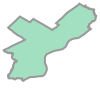

In [21]:
city_limits_outline

Use osmnx to query OpenStreetMap to get all subway stations within the city limits:

In [22]:
# Get the subway stops within the city limits
subway = ox.features_from_polygon(city_limits_outline, tags={"station": "subway"})

# Convert to 3857 (meters)
subway = subway.to_crs(epsg=3857)

Get the distance to the nearest subway station ($k=1$):

In [23]:
# STEP 1: x/y coordinates of subway stops (in EPGS=3857)
subwayXY = get_xy_from_geometry(subway.to_crs(epsg=3857))

# STEP 2: Initialize the algorithm
nbrs = NearestNeighbors(n_neighbors=1)

# STEP 3: Fit the algorithm on the "neighbors" dataset
nbrs.fit(subwayXY)

# STEP 4: Get distances for sale to neighbors
subwayDists, subwayIndices = nbrs.kneighbors(salesXY)

# STEP 5: add back to the original dataset
sales["logDistSubway"] = np.log10(subwayDists.mean(axis=1))

In [24]:
sales.head()

,sale_price,total_livable_area,total_area,garage_spaces,fireplaces,number_of_bathrooms,number_of_bedrooms,number_stories,exterior_condition,zip_code,geometry,logDistGraffiti,logDistSubway
982,450000.0,1785.0,1625.0,1.0,1.0,2.0,3.0,3.0,4,19147,POINT (-75.1486 39.93145),2.097718,3.337322
12359,670000.0,2244.0,1224.0,0.0,0.0,3.0,4.0,3.0,3,19147,POINT (-75.14818 39.93101),2.215417,3.350337
9721,790000.0,2514.0,1400.0,1.0,0.0,4.0,3.0,2.0,3,19147,POINT (-75.1478 39.9301),2.194509,3.362296
3065,195000.0,1358.0,840.0,0.0,0.0,2.0,3.0,3.0,4,19147,POINT (-75.14887 39.93026),2.212881,3.339347
11720,331000.0,868.0,546.0,0.0,0.0,2.0,2.0,2.0,4,19147,POINT (-75.14881 39.93012),2.206706,3.340635


## Now, let's run the model...

In [25]:
# Numerical columns
num_cols = [
    "total_livable_area",
    "total_area",
    "garage_spaces",
    "fireplaces",
    "number_of_bathrooms",
    "number_of_bedrooms",
    "number_stories",
    "logDistGraffiti", # NEW
    "logDistSubway" # NEW
]

# Categorical columns
cat_cols = ["exterior_condition", "zip_code"]

In [26]:
# Set up the column transformer with two transformers
transformer = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

In [27]:
# Initialize the pipeline
# NOTE: only use 20 estimators here so it will run in a reasonable time
pipe = make_pipeline(
    transformer, RandomForestRegressor(n_estimators=20, random_state=42)
)

In [28]:
# Split the data 70/30
train_set, test_set = train_test_split(sales, test_size=0.3, random_state=42)

# the target labels
y_train = np.log(train_set["sale_price"])
y_test = np.log(test_set["sale_price"])

In [29]:
# Fit the training set
# REMINDER: use the training dataframe objects here rather than numpy array
pipe.fit(train_set, y_train);

In [30]:
# What's the test score?
# REMINDER: use the test dataframe rather than numpy array
pipe.score(test_set, y_test)

0.6088137040378597

### Can we improve on this?

## Exercise from last lecture: How about other spatial features?

- I've listed out several other types of potential sources of new distance-based features from OpenDataPhilly
- Choose a few and add new features
- Re-fit the model and evalute the performance on the test set and feature importances

### 1. Universities

New feature: Distance to the *nearest* university/college

- Source: [OpenDataPhilly](https://www.opendataphilly.org/dataset/philadelphia-universities-and-colleges)
- [GeoJSON URL](https://opendata.arcgis.com/api/v3/datasets/8ad76bc179cf44bd9b1c23d6f66f57d1_0/downloads/data?format=geojson&spatialRefId=4326)


In [31]:
# Get the data
url = "https://opendata.arcgis.com/api/v3/datasets/8ad76bc179cf44bd9b1c23d6f66f57d1_0/downloads/data?format=geojson&spatialRefId=4326"
univs = gpd.read_file(url)

# Get the X/Y
univXY = get_xy_from_geometry(univs.to_crs(epsg=3857))

# Run the k nearest algorithm
nbrs = NearestNeighbors(n_neighbors=1)
nbrs.fit(univXY)
univDists, _ = nbrs.kneighbors(salesXY)

# Add the new feature
sales['logDistUniv'] = np.log10(univDists.mean(axis=1))

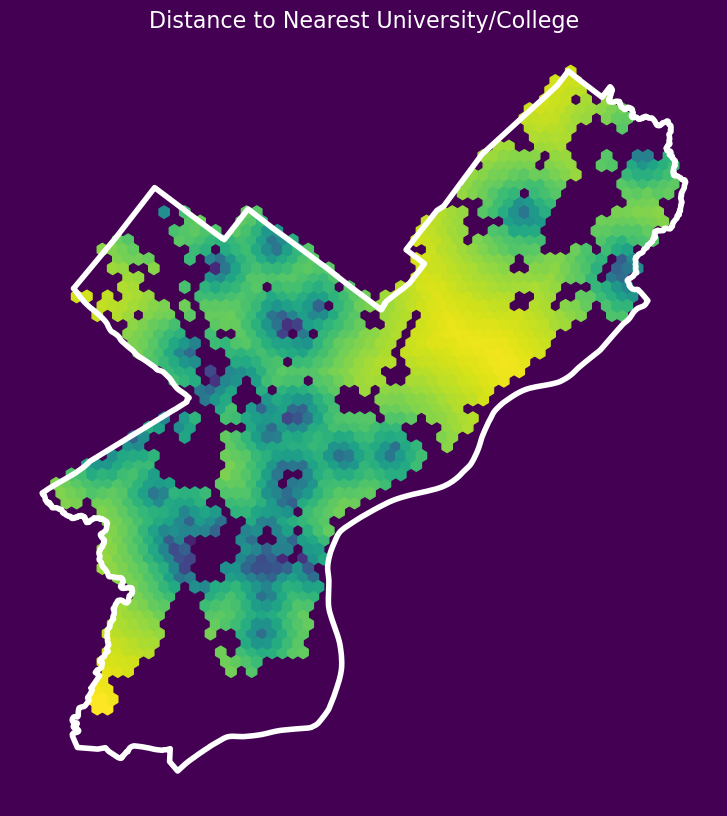

In [32]:
fig, ax = plt.subplots(figsize=(10,10), facecolor=plt.get_cmap('viridis')(0))

x = salesXY[:,0]
y = salesXY[:,1]
ax.hexbin(x, y, C=np.log10(univDists.mean(axis=1)), gridsize=60)

# Plot the city limits
city_limits.plot(ax=ax, facecolor='none', edgecolor='white', linewidth=4)

ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title("Distance to Nearest University/College", fontsize=16, color='white');

### 2. Parks

New feature: Distance to the *nearest* park centroid

* Source: [OpenDataPhilly](https://www.opendataphilly.org/dataset/ppr-properties)
* [GeoJSON URL](https://opendata.arcgis.com/datasets/d52445160ab14380a673e5849203eb64_0.geojson)

**Notes** 
- The park geometries are *polygons*, so you'll need to get the `x` and `y` coordinates of the park *centroids* and calculate the distance to these centroids. 
- You can use the `geometry.centroid.x` and `geometry.centroid.y` values to access these coordinates.

In [33]:
# Get the data
url = "https://opendata.arcgis.com/datasets/d52445160ab14380a673e5849203eb64_0.geojson"
parks = gpd.read_file(url)

# Get the X/Y 
parksXY = get_xy_from_geometry(parks.to_crs(epsg=3857))

# Run the k nearest algorithm
nbrs = NearestNeighbors(n_neighbors=1)
nbrs.fit(parksXY)
parksDists, _ = nbrs.kneighbors(salesXY)

# Add the new feature
sales["logDistParks"] = np.log10(parksDists.mean(axis=1))

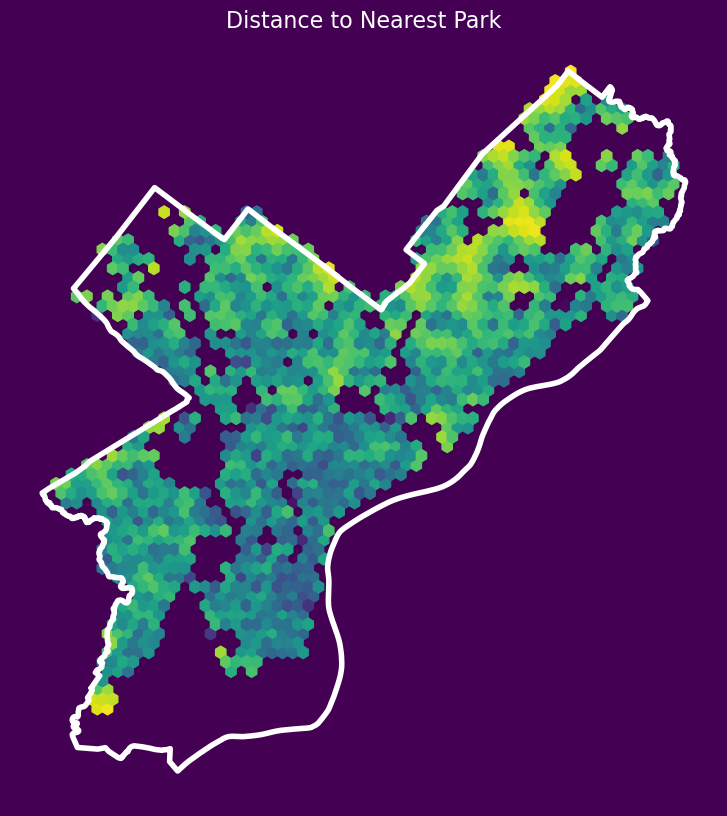

In [34]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor=plt.get_cmap("viridis")(0))

x = salesXY[:, 0]
y = salesXY[:, 1]
ax.hexbin(x, y, C=np.log10(parksDists.mean(axis=1)), gridsize=60)

# Plot the city limits
city_limits.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=4)

ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title("Distance to Nearest Park", fontsize=16, color="white");

### 3. City Hall

New feature: Distance to City Hall.

* Source: [OpenDataPhilly](https://www.opendataphilly.org/dataset/city-landmarks)
* [GeoJSON URL](http://data-phl.opendata.arcgis.com/datasets/5146960d4d014f2396cb82f31cd82dfe_0.geojson)

**Notes**

- To identify City Hall, you'll need to pull data where "NAME='City Hall'" and "FEAT_TYPE='Municipal Building'"
- As with the parks, the geometry will be a *polygon*, so you should calculate the distance to the *centroid* of the City Hall polygon

In [35]:
# Get the data
url = "http://data-phl.opendata.arcgis.com/datasets/5146960d4d014f2396cb82f31cd82dfe_0.geojson"
landmarks = gpd.read_file(url)

# Trim to City Hall
cityHall = landmarks.query("NAME == 'City Hall' and FEAT_TYPE == 'Municipal Building'")

In [36]:
# Get the X/Y
cityHallXY = get_xy_from_geometry(cityHall.to_crs(epsg=3857))

# Run the k nearest algorithm
nbrs = NearestNeighbors(n_neighbors=1)
nbrs.fit(cityHallXY)
cityHallDist, _ = nbrs.kneighbors(salesXY)

# Add the new feature
sales["logDistCityHall"] = np.log10(cityHallDist.mean(axis=1))

In [37]:
cityHallXY.shape

(1, 2)

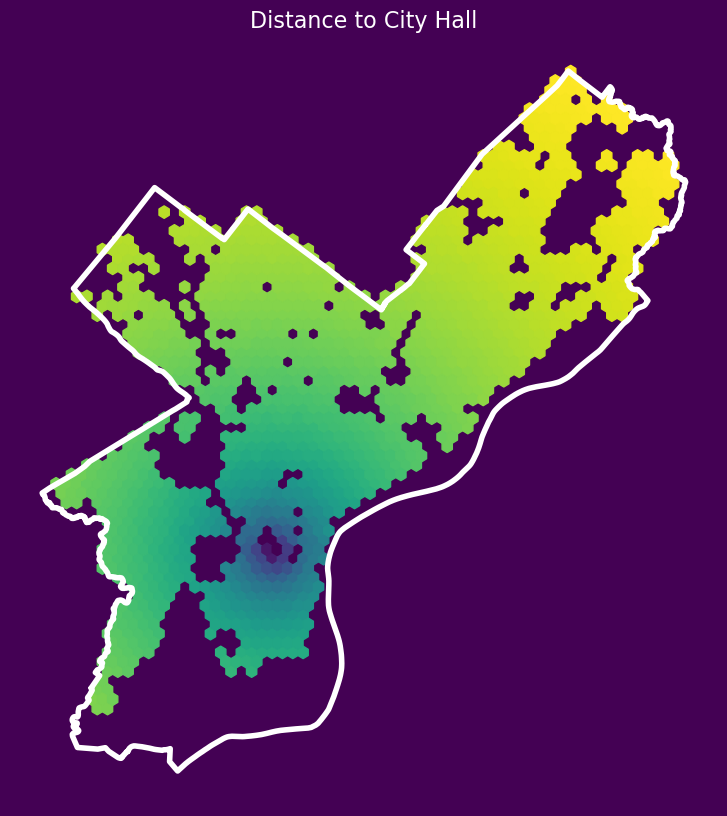

In [38]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor=plt.get_cmap("viridis")(0))

x = salesXY[:, 0]
y = salesXY[:, 1]
ax.hexbin(x, y, C=np.log10(cityHallDist.mean(axis=1)), gridsize=60)

# Plot the city limits
city_limits.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=4)

ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title("Distance to City Hall", fontsize=16, color="white");

### 5. Aggravated Assaults

New feature: Distance to the 5 nearest aggravated assaults in 2022

* Source: [OpenDataPhilly](https://www.opendataphilly.org/dataset/crime-incidents)
* CARTO table name: "incidents_part1_part2"

**Notes**

* You can pull aggravated assaults only by selecting where `Text_General_Code` equals 'Aggravated Assault No Firearm' or 'Aggravated Assault Firearm'
* You can select crimes from only 2022 using the `dispatch_date` column

In [39]:
# Table name
table_name = "incidents_part1_part2"

# Where selection
where = "dispatch_date >= '2022-01-01' AND dispatch_date < '2023-01-01'"
where = where + " AND Text_General_Code IN ('Aggravated Assault No Firearm', 'Aggravated Assault Firearm')"

# Query
assaults = get_carto_data(table_name, where=where)

# Remove missing 
not_missing = ~assaults.geometry.is_empty & assaults.geometry.notna()
assaults = assaults.loc[not_missing]
    
# Get the X/Y
assaultsXY = get_xy_from_geometry(assaults.to_crs(epsg=3857))

# Run the k nearest algorithm
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(assaultsXY)
assaultDists, _ = nbrs.kneighbors(salesXY)

# Add the new feature
sales['logDistAssaults'] = np.log10(assaultDists.mean(axis=1))

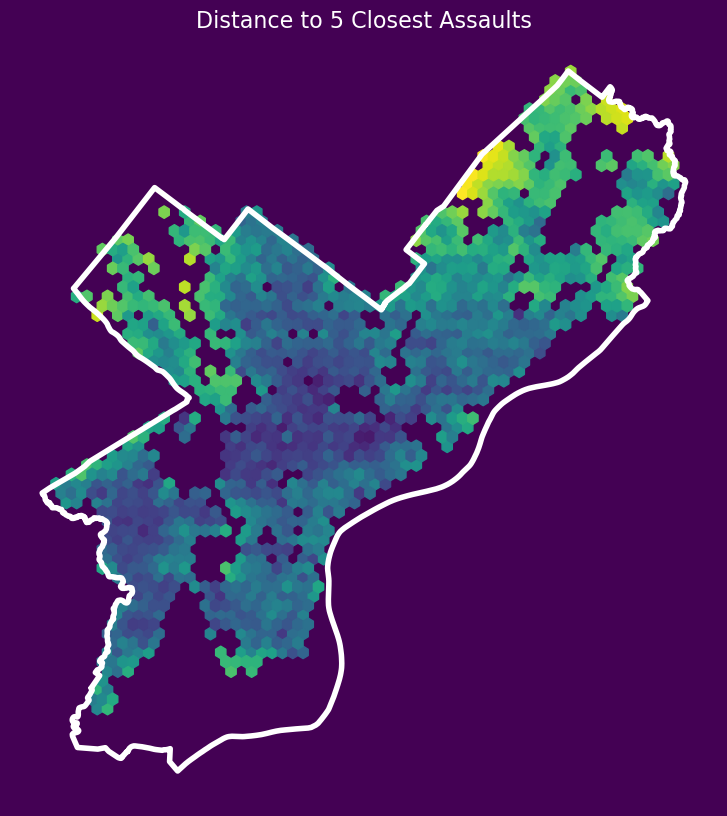

In [40]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor=plt.get_cmap("viridis")(0))

x = salesXY[:, 0]
y = salesXY[:, 1]
ax.hexbin(x, y, C=np.log10(assaultDists.mean(axis=1)), gridsize=60)

# Plot the city limits
city_limits.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=4)

ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title("Distance to 5 Closest Assaults", fontsize=16, color="white");

### 6. Abandonded Vehicle 311 Calls

New feature: Distance to the 5 nearest abandoned vehicle 311 calls in 2022

* Source: [OpenDataPhilly](https://www.opendataphilly.org/dataset/311-service-and-information-requests)
* CARTO table name: "public_cases_fc"

**Notes**

* You can pull abandonded vehicle calls only by selecting where `service_name` equals 'Abandoned Vehicle'
* You can select crimes from only 2022 using the `requested_datetime` column

In [41]:
# Table name
table_name = "public_cases_fc"

# Where selection
where = "requested_datetime >= '2022-01-01' AND requested_datetime < '2023-01-01'"
where = "service_name = 'Abandoned Vehicle'"

# Query
cars = get_carto_data(table_name, where=where)

# Remove missing
not_missing = ~cars.geometry.is_empty & cars.geometry.notna()
cars = cars.loc[not_missing]

# Get the X/Y
carsXY = get_xy_from_geometry(cars.to_crs(epsg=3857))

# Run the k nearest algorithm
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(carsXY)
carDists, _ = nbrs.kneighbors(salesXY)

# Handle any sales that have 0 distances
carDists[carDists == 0] = 1e-5  # a small, arbitrary value

# Add the new feature
sales["logDistCars"] = np.log10(carDists.mean(axis=1))

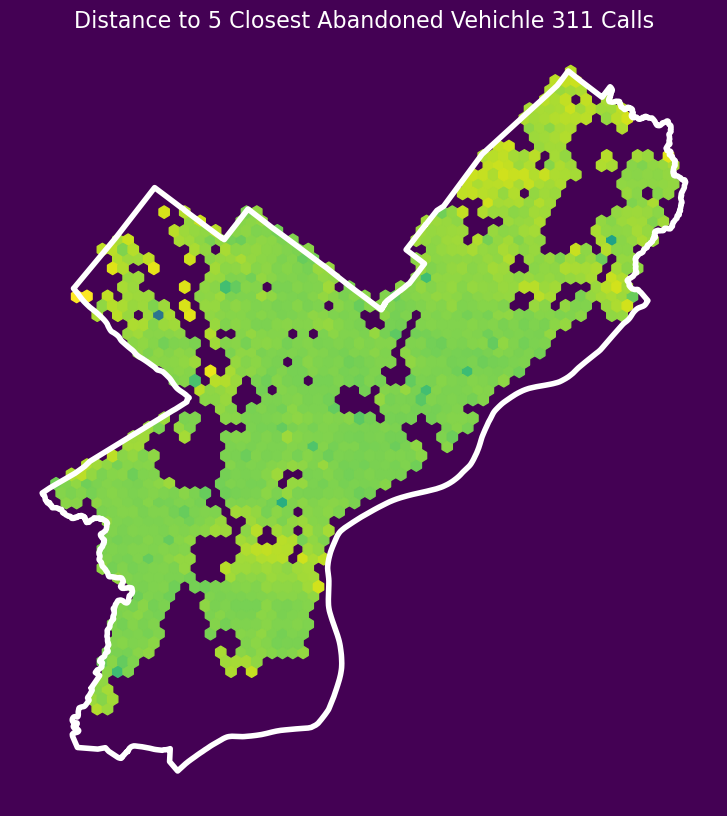

In [42]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor=plt.get_cmap("viridis")(0))

x = salesXY[:, 0]
y = salesXY[:, 1]
ax.hexbin(x, y, C=np.log10(carDists.mean(axis=1)), gridsize=60)

# Plot the city limits
city_limits.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=4)

ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(
    "Distance to 5 Closest Abandoned Vehichle 311 Calls", fontsize=16, color="white"
);

## Fit the updated model

In [43]:
# Numerical columns
num_cols = [
    "total_livable_area",
    "total_area",
    "garage_spaces",
    "fireplaces",
    "number_of_bathrooms",
    "number_of_bedrooms",
    "number_stories",
    "logDistGraffiti", # NEW
    "logDistSubway", # NEW
    "logDistUniv", # NEW
    "logDistParks", # NEW
    "logDistCityHall", # NEW 
    # "logDistPermits", # NEW
    "logDistAssaults", # NEW
    "logDistCars" # NEW
]

# Categorical columns
cat_cols = ["exterior_condition", "zip_code"]

In [44]:
# Set up the column transformer with two transformers
transformer = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

In [45]:
# Two steps in pipeline: preprocessor and then regressor
pipe = make_pipeline(
    transformer, RandomForestRegressor(n_estimators=20, random_state=42)
)

In [46]:
# Split the data 70/30
train_set, test_set = train_test_split(sales, test_size=0.3, random_state=42)

# the target labels
y_train = np.log(train_set["sale_price"])
y_test = np.log(test_set["sale_price"])

In [47]:
# Fit the training set
pipe.fit(train_set, y_train);

In [48]:
# What's the test score?
pipe.score(test_set, y_test)

0.6403082333741033

### More improvement!


### Feature importances:

In [49]:
# The one-hot step
ohe = transformer.named_transformers_["cat"]

# One column for each category type!
ohe_cols = ohe.get_feature_names_out()

# Full list of columns is numerical + one-hot
features = num_cols + list(ohe_cols)

# The regressor
regressor = pipe["randomforestregressor"]

# Create the dataframe with importances
importance = pd.DataFrame(
    {"Feature": features, "Importance": regressor.feature_importances_}
)

# Sort importance in descending order and get the top
importance = importance.sort_values("Importance", ascending=False).iloc[:30]

# Plot
importance.hvplot.barh(
    x="Feature", y="Importance", flip_yaxis=True, height=500
)

:Bars   [Feature]   (Importance)

## Part 2: Predicting bikeshare demand in Philadelphia

**The technical problem**: predict bikeshare trip counts for the Indego bikeshare in Philadelphia



### The policy question: how to best expand a bikeshare program?

- Bikeshares typically require substantial capital when first launching, about \\$4,000 to \\$5,000 per bike
- Once launched, revenue from riders typically covers about 80 percent of operating costs
- Ridership peaks in busy downtown hubs, but how to best expand outwards, often to low-density and low-income communities?
- Important cost/benefit questions of how/where to expand to maximize ridership and access and minimize the need for outside subsidies

For more info, see [this blog post](https://www.pewtrusts.org/en/research-and-analysis/blogs/stateline/2016/03/24/despite-popularity-bike-share-programs-often-need-subsidies) from Pew

### Using predictive modeling as a policy tool

- Construct a predictive model for trip counts by stations in a bikeshare
- Use this model to estimate and map out the ridership for potential stations in new areas
- Use the cost per ride to estimate the additional revenue added
- Compare this additional revenue to the cost of adding new stations

### What are the key assumptions here?

**Most important:** adding new stations in new areas will not affect the demand for existing stations.

This allows the results from the predictive model for demand, built on existing stations, to translate to new stations. 

The key assumption is that the bikeshare is not yet at full capacity, and riders in new areas will not decrease the demand in other areas.

### Is this a good assumption?

- Given that the bikeshare is looking to expand, it's a safe bet that they believe the program is not yet at full capacity
- This is verifiable with existing data — examine trip counts in neighboring stations when a new station opens up. 

**Typically, this is a pretty safe assumption.** But I encourage you to use historical data to verify it!

### Getting trip data for the Indego bike share

- Available by quarter from: [https://www.rideindego.com/about/data/](https://www.rideindego.com/about/data/)
- I've pulled historic trip data from 2018 through 2023 and combined into a single CSV file (available in the data folder)

The data page also includes the live status of all of the stations in the system.

API endpoint: [http://www.rideindego.com/stations/json](http://www.rideindego.com/stations/json)

**Two important columns:**

- `totalDocks`: the total number of docks at each station
- `kioskId`: the unique identifier for each station

In [50]:
# API endpoint
API_endpoint = "http://www.rideindego.com/stations/json"

# Get the JSON
stations_geojson = requests.get(API_endpoint).json()

# Convert to a GeoDataFrame
stations = gpd.GeoDataFrame.from_features(stations_geojson, crs="EPSG:4326")

In [51]:
stations.head()

,geometry,id,name,coordinates,totalDocks,docksAvailable,bikesAvailable,classicBikesAvailable,smartBikesAvailable,electricBikesAvailable,rewardBikesAvailable,rewardDocksAvailable,kioskStatus,kioskPublicStatus,kioskConnectionStatus,kioskType,addressStreet,addressCity,addressState,addressZipCode,bikes,closeTime,eventEnd,eventStart,isEventBased,isVirtual,kioskId,notes,openTime,publicText,timeZone,trikesAvailable,latitude,longitude
0,POINT (-75.14403 39.94733),3005,"Welcome Park, NPS","[-75.14403, 39.94733]",13,6,7,1,0,6,7,6,FullService,Active,Active,1,191 S. 2nd St.,Philadelphia,PA,19106,"[{'dockNumber': 2, 'isElectric': False, 'isAva...",None,None,None,False,False,3005,None,None,,None,0,39.94733,-75.14403
1,POINT (-75.20311 39.9522),3006,40th & Spruce,"[-75.20311, 39.9522]",17,13,4,0,0,4,4,12,FullService,Active,Active,1,246 S. 40th St.,Philadelphia,PA,19104,"[{'dockNumber': 3, 'isElectric': True, 'isAvai...",None,None,None,False,False,3006,None,None,,None,0,39.95220,-75.20311
2,POINT (-75.15993 39.94517),3007,"11th & Pine, Kahn Park","[-75.15993, 39.94517]",20,15,2,1,0,1,2,17,FullService,Active,Active,1,328 S. 11th St.,Philadelphia,PA,19107,"[{'dockNumber': 4, 'isElectric': False, 'isAva...",None,None,None,False,False,3007,None,None,,None,0,39.94517,-75.15993
3,POINT (-75.15067 39.98081),3008,Temple University Station,"[-75.15067, 39.98081]",17,13,1,1,0,0,1,15,FullService,Active,Active,1,1076 Berks Street,Philadelphia,PA,19122,"[{'dockNumber': 3, 'isElectric': False, 'isAva...",None,None,None,False,False,3008,None,None,,None,0,39.98081,-75.15067
4,POINT (-75.18982 39.95576),3009,33rd & Market,"[-75.18982, 39.95576]",14,9,5,1,0,4,5,9,FullService,Active,Active,1,3318 Market St.,Philadelphia,PA,19104,"[{'dockNumber': 3, 'isElectric': True, 'isAvai...",None,None,None,False,False,3009,None,None,,None,0,39.95576,-75.18982


### Let's plot the stations, colored by the number of docks

Use the [contextily](https://contextily.readthedocs.io/en/latest/index.html) package to add a static basemap underneath the matplotlib plot of the stations.


In [52]:
import contextily as ctx

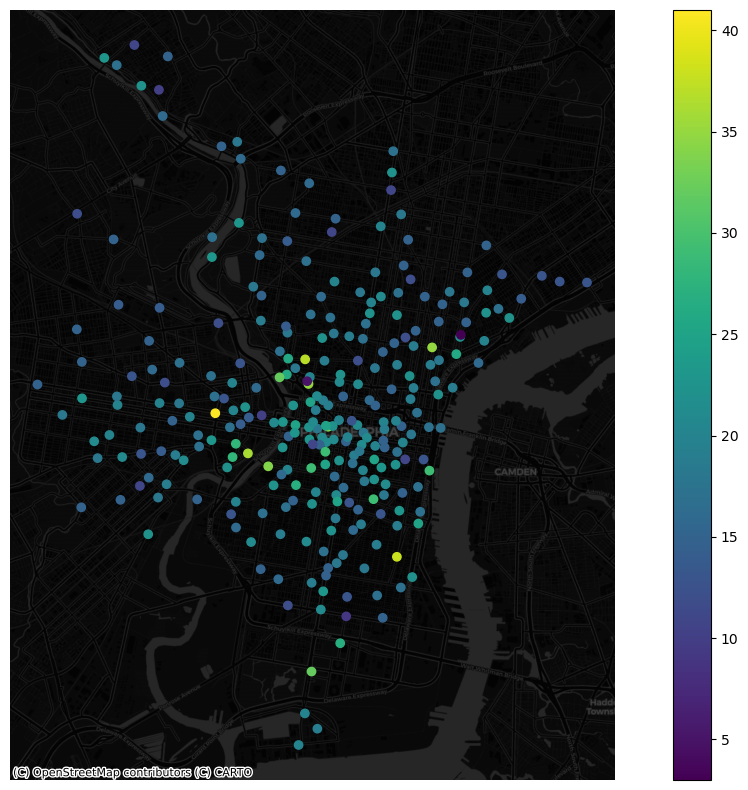

In [53]:
fig, ax = plt.subplots(figsize=(15, 10))

# stations
stations_3857 = stations.to_crs(epsg=3857)
stations_3857.plot(ax=ax, column='totalDocks', legend=True)

# plot the basemap underneath
ctx.add_basemap(ax=ax, crs=stations_3857.crs, source=ctx.providers.CartoDB.DarkMatter)

ax.set_axis_off()

### Load historic trips data

In [54]:
all_trips = pd.read_csv("./data/indego-trips-2018-2023.csv.tar.gz")

/var/folders/7g/px0llbj54z37p076r6853ggh0000gn/T/ipykernel_24597/751211994.py:1: DtypeWarning: Columns (10,14) have mixed types. Specify dtype option on import or set low_memory=False.
  all_trips = pd.read_csv("./data/indego-trips-2018-2023.csv.tar.gz")


In [55]:
for col in ['start_time', 'end_time']:
    all_trips[col] = pd.to_datetime(all_trips[col], format="%Y-%m-%d %H:%M:%S")

In [56]:
len(all_trips)

3898067

In [57]:
all_trips.head()

,trip_id,duration,start_time,end_time,start_station,start_lat,start_lon,end_station,end_lat,end_lon,bike_id,plan_duration,trip_route_category,passholder_type,bike_type
0,223869188,18,2018-01-01 00:24:00,2018-01-01 00:42:00,3124,39.952950,-75.139793,3073,39.961430,-75.152420,3708,30.0,One Way,Indego30,NaN
1,223872811,22,2018-01-01 00:48:00,2018-01-01 01:10:00,3026,39.941380,-75.145638,3023,39.950481,-75.172859,11735,30.0,One Way,Indego30,NaN
2,223872810,21,2018-01-01 01:03:00,2018-01-01 01:24:00,3045,39.947922,-75.162369,3037,39.954239,-75.161377,5202,30.0,One Way,Indego30,NaN
3,223872809,4,2018-01-01 01:05:00,2018-01-01 01:09:00,3115,39.972630,-75.167572,3058,39.967159,-75.170013,5142,30.0,One Way,Indego30,NaN
4,223912960,658,2018-01-01 01:14:00,2018-01-01 12:12:00,3045,39.947922,-75.162369,3000,NaN,NaN,5196,30.0,One Way,Indego30,NaN


### Dependent variable: total trips by starting station

In [58]:
start_trips = (
    all_trips.groupby("start_station").size().reset_index(name="total_start_trips")
)

In [59]:
start_trips.head()

,start_station,total_start_trips
0,3000,577
1,3004,26544
2,3005,21489
3,3006,35810
4,3007,69165


In [60]:
# Now merge in the geometry for each station
bike_data = (
    stations[["geometry", "kioskId"]]
    .merge(start_trips, left_on="kioskId", right_on="start_station")
    .to_crs(epsg=3857)
)

Let's plot it...

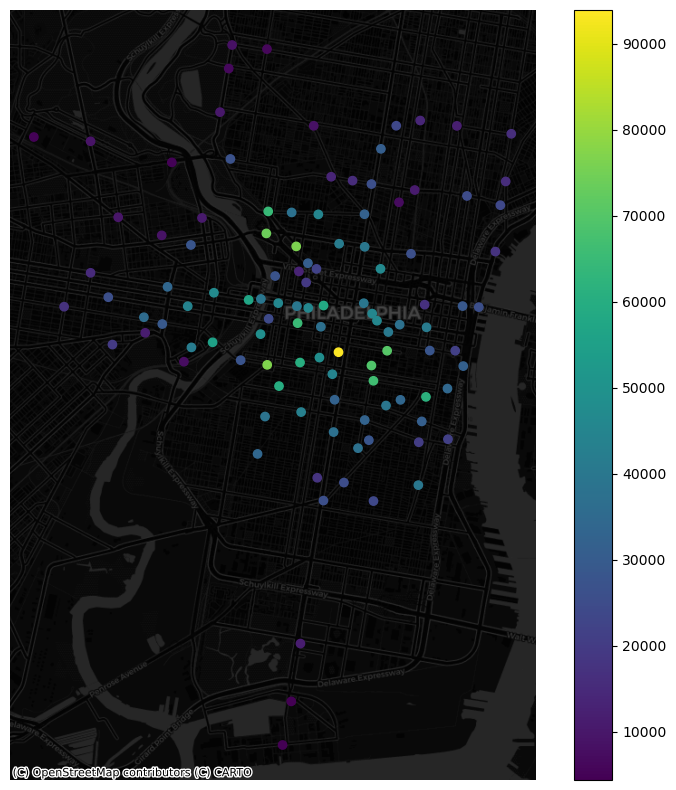

In [61]:
fig, ax = plt.subplots(figsize=(10,10))

# stations
bike_data.plot(ax=ax, column='total_start_trips', legend=True)

# plot the basemap underneath
ctx.add_basemap(ax=ax, crs=bike_data.crs, source=ctx.providers.CartoDB.DarkMatter)

ax.set_axis_off()

Trips are clearly concentrated in Center City...

### What features to use?

There are lots of possible options. Generally speaking, the possible features fall into a few different categories:

- **Internal**
    - e.g., the number of docks per station
- **Demographic (Census)**    
    - e.g., population, income, percent commuting by car, percent with bachelor's degree or higher, etc
- **Amenities/Disamenities**
    - e.g., distance to nearest crimes, restaurants, parks, within Center City, etc
- **Transportation network**
    - e.g., distance to nearest bus stop, interesection nodes, nearest subway stop
- **Neighboring stations**
    - e.g., average trips of nearest stations, distance to nearest stations
    
**Let's add a few from each category...**

### 1. Internal characteristics

Let's use the number of docks per stations:

In [62]:
bike_data = bike_data.merge(stations[["kioskId", "totalDocks"]], on="kioskId")
bike_data.head()

,geometry,kioskId,start_station,total_start_trips,totalDocks
0,POINT (-8364995.156 4858291.368),3005,3005,21489,13
1,POINT (-8371571.911 4858998.543),3006,3006,35810,17
2,POINT (-8366765.136 4857977.729),3007,3007,69165,20
3,POINT (-8365734.317 4863154.033),3008,3008,13899,17
4,POINT (-8370092.475 4859515.524),3009,3009,47041,14


### 2. Census demographic data

We'll try out percent commuting by car first.

In [63]:
import cenpy

/opt/anaconda3/envs/geospatial/lib/python3.10/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [64]:
acs = cenpy.remote.APIConnection("ACSDT5Y2021")

In [65]:
acs.varslike("B08134").sort_index().iloc[:15]

,label,concept,predicateType,group,limit,predicateOnly,hasGeoCollectionSupport,attributes,required
B08134_001E,Estimate!!Total:,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_001EA,B08134_001M,B08134_001MA",NaN
B08134_002E,Estimate!!Total:!!Less than 10 minutes,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_002EA,B08134_002M,B08134_002MA",NaN
B08134_003E,Estimate!!Total:!!10 to 14 minutes,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_003EA,B08134_003M,B08134_003MA",NaN
B08134_004E,Estimate!!Total:!!15 to 19 minutes,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_004EA,B08134_004M,B08134_004MA",NaN
B08134_005E,Estimate!!Total:!!20 to 24 minutes,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_005EA,B08134_005M,B08134_005MA",NaN
B08134_006E,Estimate!!Total:!!25 to 29 minutes,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_006EA,B08134_006M,B08134_006MA",NaN
B08134_007E,Estimate!!Total:!!30 to 34 minutes,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_007EA,B08134_007M,B08134_007MA",NaN
B08134_008E,Estimate!!Total:!!35 to 44 minutes,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_008EA,B08134_008M,B08134_008MA",NaN
B08134_009E,Estimate!!Total:!!45 to 59 minutes,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_009EA,B08134_009M,B08134_009MA",NaN
B08134_010E,Estimate!!Total:!!60 or more minutes,MEANS OF TRANSPORTATION TO WORK BY TRAVEL TIME...,int,B08134,0,NaN,NaN,"B08134_010EA,B08134_010M,B08134_010MA",NaN


In [66]:
# Means of Transportation to Work by Travel Time to Work
variables = ["NAME", "B08134_001E", "B08134_011E"]

# Pull data by census tract
census_data = acs.query(
    cols=variables,
    geo_unit="block group:*",
    geo_filter={"state": "42",
                "county": "101", 
                "tract": "*"},
)

# Convert to the data to floats
for col in variables[1:]:
    census_data[col] = census_data[col].astype(float)

# The percent commuting by car
census_data["percent_car"] = census_data["B08134_011E"] / census_data["B08134_001E"]

In [67]:
census_data.head()

,NAME,B08134_001E,B08134_011E,state,county,tract,block group,percent_car
0,"Block Group 1, Census Tract 1.01, Philadelphia...",0.0,0.0,42,101,000101,1,NaN
1,"Block Group 2, Census Tract 1.01, Philadelphia...",0.0,0.0,42,101,000101,2,NaN
2,"Block Group 3, Census Tract 1.01, Philadelphia...",0.0,0.0,42,101,000101,3,NaN
3,"Block Group 4, Census Tract 1.01, Philadelphia...",763.0,313.0,42,101,000101,4,0.410223
4,"Block Group 5, Census Tract 1.01, Philadelphia...",479.0,191.0,42,101,000101,5,0.398747


Merge with block group geometries for Philadelphia:

In [68]:
import pygris

In [69]:
# Query for tracts
block_groups = pygris.block_groups(state='42', county='101', year=2021)

In [70]:
census_data = block_groups.merge(
    census_data,
    left_on=["STATEFP", "COUNTYFP", "TRACTCE", "BLKGRPCE"],
    right_on=["state", "county", "tract", "block group"],
)

Finally, let's merge the census data into our dataframe of features by spatially joining the stations and the block groups:

**Each station gets the census data associated with the block group the station is within.**

In [71]:
bike_data = gpd.sjoin(
    bike_data,
    census_data.to_crs(bike_data.crs)[["geometry", "percent_car"]],
    predicate="within",
).drop(labels=["index_right"], axis=1)

In [72]:
bike_data.head()

,geometry,kioskId,start_station,total_start_trips,totalDocks,percent_car
0,POINT (-8364995.156 4858291.368),3005,3005,21489,13,0.509434
1,POINT (-8371571.911 4858998.543),3006,3006,35810,17,0.046414
2,POINT (-8366765.136 4857977.729),3007,3007,69165,20,0.188889
3,POINT (-8365734.317 4863154.033),3008,3008,13899,17,0.423333
4,POINT (-8370092.475 4859515.524),3009,3009,47041,14,0.208978


#### "Impute" missing values with the median value

Note: scikit-learn contains preprocessing transformers to do more advanced imputation methods. [The documentation](https://scikit-learn.org/stable/modules/impute.html) contains a good description of the options. 

In particular, the `SimpleImputer` object (see the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)) can fill values based on the median, mean, most frequent value, or a constant value.

In [73]:
missing = bike_data['percent_car'].isnull()
bike_data.loc[missing, 'percent_car'] = bike_data['percent_car'].median()

### 3. Amenities/disamenities

Let's add two new features:

1. Distances to the nearest 10 restaurants from Open Street Map
1. Whether the station is located within Center City

#### Restaurants

Search https://wiki.openstreetmap.org/wiki/Map_Features for OSM identifier of restaurants

In [74]:
restaurants = ox.features_from_polygon(
    city_limits_outline, tags={"amenity": "restaurant"}
).to_crs(epsg=3857)

restaurants.head()

geometry     addr:city  \
element id                                                          
node    333786044  POINT (-8366653.605 4857351.702)  Philadelphia   
        566683522  POINT (-8366499.795 4860429.601)  Philadelphia   
        596230881  POINT (-8369759.051 4873925.895)           NaN   
        596245658  POINT (-8370151.987 4874548.737)  Philadelphia   
        596245661  POINT (-8370193.386 4874608.965)  Philadelphia   

                  addr:housenumber addr:postcode addr:state  \
element id                                                    
node    333786044              735         19147         PA   
        566683522             1139         19123        NaN   
        596230881              NaN           NaN        NaN   
        596245658             7136         19119         PA   
        596245661             7152         19119         PA   

                            addr:street             alt_name     amenity  atm  \
element id                                                                      
node    333786044     South 10th Street  Morning Glory Diner  restaurant  yes   
        566683522  Spring Garden Street                  NaN  restaurant  NaN   
        596230881                   NaN                  NaN  restaurant  NaN   
        596245658     Germantown Avenue                  NaN  restaurant  NaN   
        596245661     Germantown Avenue                  NaN  restaurant  NaN   

                                              contact:facebook   cuisine  \
element id                                                                 
node    333786044  https://www.facebook.com/MorningGloryDiner/     diner   
        566683522                                          NaN     pizza   
        596230881                                          NaN       NaN   
        596245658                                          NaN       NaN   
        596245661                                          NaN  american   

                  diet:vegetarian                              name  \
element id                                                            
node    333786044             yes               Sam's Morning Glory   
        566683522             NaN  Spring Garden Pizza & Restaurant   
        596230881             NaN                               NaN   
        596245658             NaN             Earth Bread & Brewery   
        596245661             NaN    Cresheim Valley Grain Exchange   

                                               opening_hours payment:cash  \
element id                                                                  
node    333786044       Mo-Fr 08:00-14:00; Sa,Su 08:00-15:00          yes   
        566683522  Mo-Fr 08:00-20:00; Sa 08:00-17:00; Su off          NaN   
        596230881                                        NaN          NaN   
        596245658                                        NaN          NaN   
        596245661                                        NaN          NaN   

                  payment:credit_cards payment:debit_cards            source  \
element id                                                                     
node    333786044                   no                  no  knowledge;survey   
        566683522                  NaN                 NaN               NaN   
        596230881                  NaN                 NaN               NaN   
        596245658                  NaN                 NaN               NaN   
        596245661                  NaN                 NaN               NaN   

                  wheelchair  check_date            phone  \
element id                                                  
node    333786044    limited         NaN              NaN   
        566683522        NaN  2023-10-11  +1 215-765-7665   
        596230881        NaN         NaN              NaN   
        596245658        NaN         NaN              NaN   
        596245661        NaN         NaN           

Get x/y values for the stations:

In [75]:
stationsXY = get_xy_from_geometry(bike_data)

In [76]:
# STEP 1: x/y coordinates of restaurants (in EPGS=3857)
restsXY = get_xy_from_geometry(restaurants.to_crs(epsg=3857))

# STEP 2: Initialize the algorithm
nbrs = NearestNeighbors(n_neighbors=10)

# STEP 3: Fit the algorithm on the "neighbors" dataset
nbrs.fit(restsXY)

# STEP 4: Get distances for stations to neighbors
restsDists, restsIndices = nbrs.kneighbors(stationsXY)

# STEP 5: add back to the original dataset
bike_data['logDistRests'] = np.log10(restsDists.mean(axis=1))

In [77]:
bike_data.head()

,geometry,kioskId,start_station,total_start_trips,totalDocks,percent_car,logDistRests
0,POINT (-8364995.156 4858291.368),3005,3005,21489,13,0.509434,2.216378
1,POINT (-8371571.911 4858998.543),3006,3006,35810,17,0.046414,2.425005
2,POINT (-8366765.136 4857977.729),3007,3007,69165,20,0.188889,2.575000
3,POINT (-8365734.317 4863154.033),3008,3008,13899,17,0.423333,2.771241
4,POINT (-8370092.475 4859515.524),3009,3009,47041,14,0.208978,2.583877


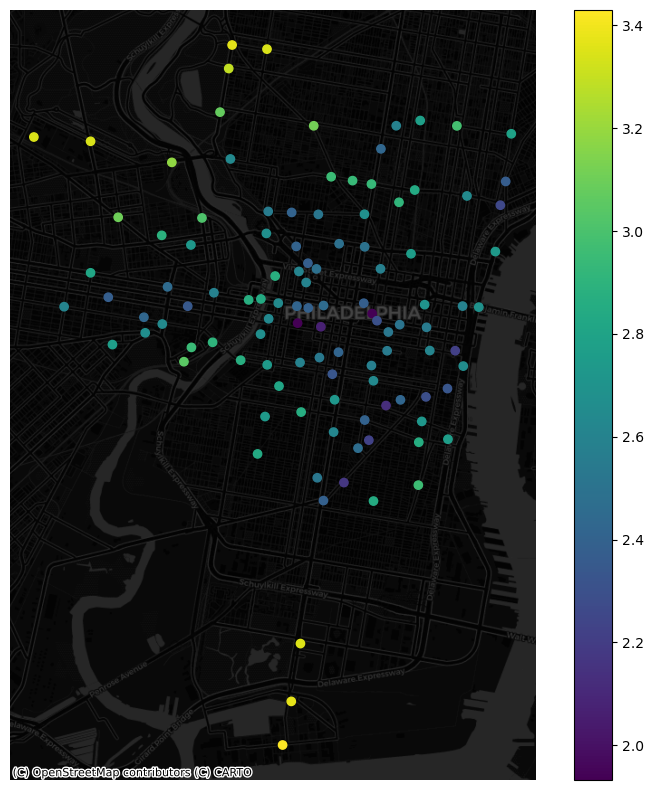

In [78]:
fig, ax = plt.subplots(figsize=(10,10))

# stations
bike_data.plot(ax=ax, column='logDistRests', legend=True)

# plot the basemap underneath
ctx.add_basemap(ax=ax, crs=bike_data.crs, source=ctx.providers.CartoDB.DarkMatter)

ax.set_axis_off()

#### Within the Center City business district

Available from [OpenDataPhilly](https://www.opendataphilly.org/dataset/center-city-business-improvement-district)

In [79]:
url = "http://data.phl.opendata.arcgis.com/datasets/95366b115d93443eae4cc6f498cb3ca3_0.geojson"
ccbd = gpd.read_file(url).to_crs(epsg=3857)

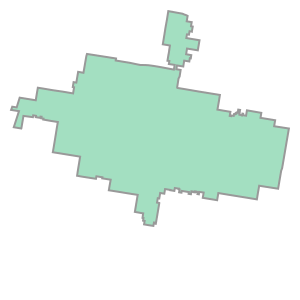

In [80]:
ccbd_geo = ccbd.squeeze().geometry

ccbd_geo

In [81]:
# Add the new feature: 1 if within CC and 0 otherwise
bike_data['within_centerCity'] = bike_data.geometry.within(ccbd_geo).astype(int)

### 4. Transportation Network

- Let's add a feature that calculates the distance to the nearest intersections
- We can use the osmnx package

In [82]:
xmin, ymin, xmax, ymax = bike_data.to_crs(epsg=4326).total_bounds

Create the graph object from the bounding box:

In [90]:
ymax, ymin, xmax, xmin

(39.991789999999995, 39.88994000000001, -75.13339, -75.22398999999999)

In [89]:
G = ox.graph_from_bbox((ymax, ymin, xmax, xmin), network_type='bike')
# G = ox.graph_from_bbox((ymax, ymin, xmax, xmin), network_type='bike')

G

/opt/anaconda3/envs/geospatial/lib/python3.10/site-packages/osmnx/_overpass.py:267: UserWarning: This area is 39,077 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


KeyboardInterrupt: 

Let's plot the graph using the built-in plotting from osmnx:

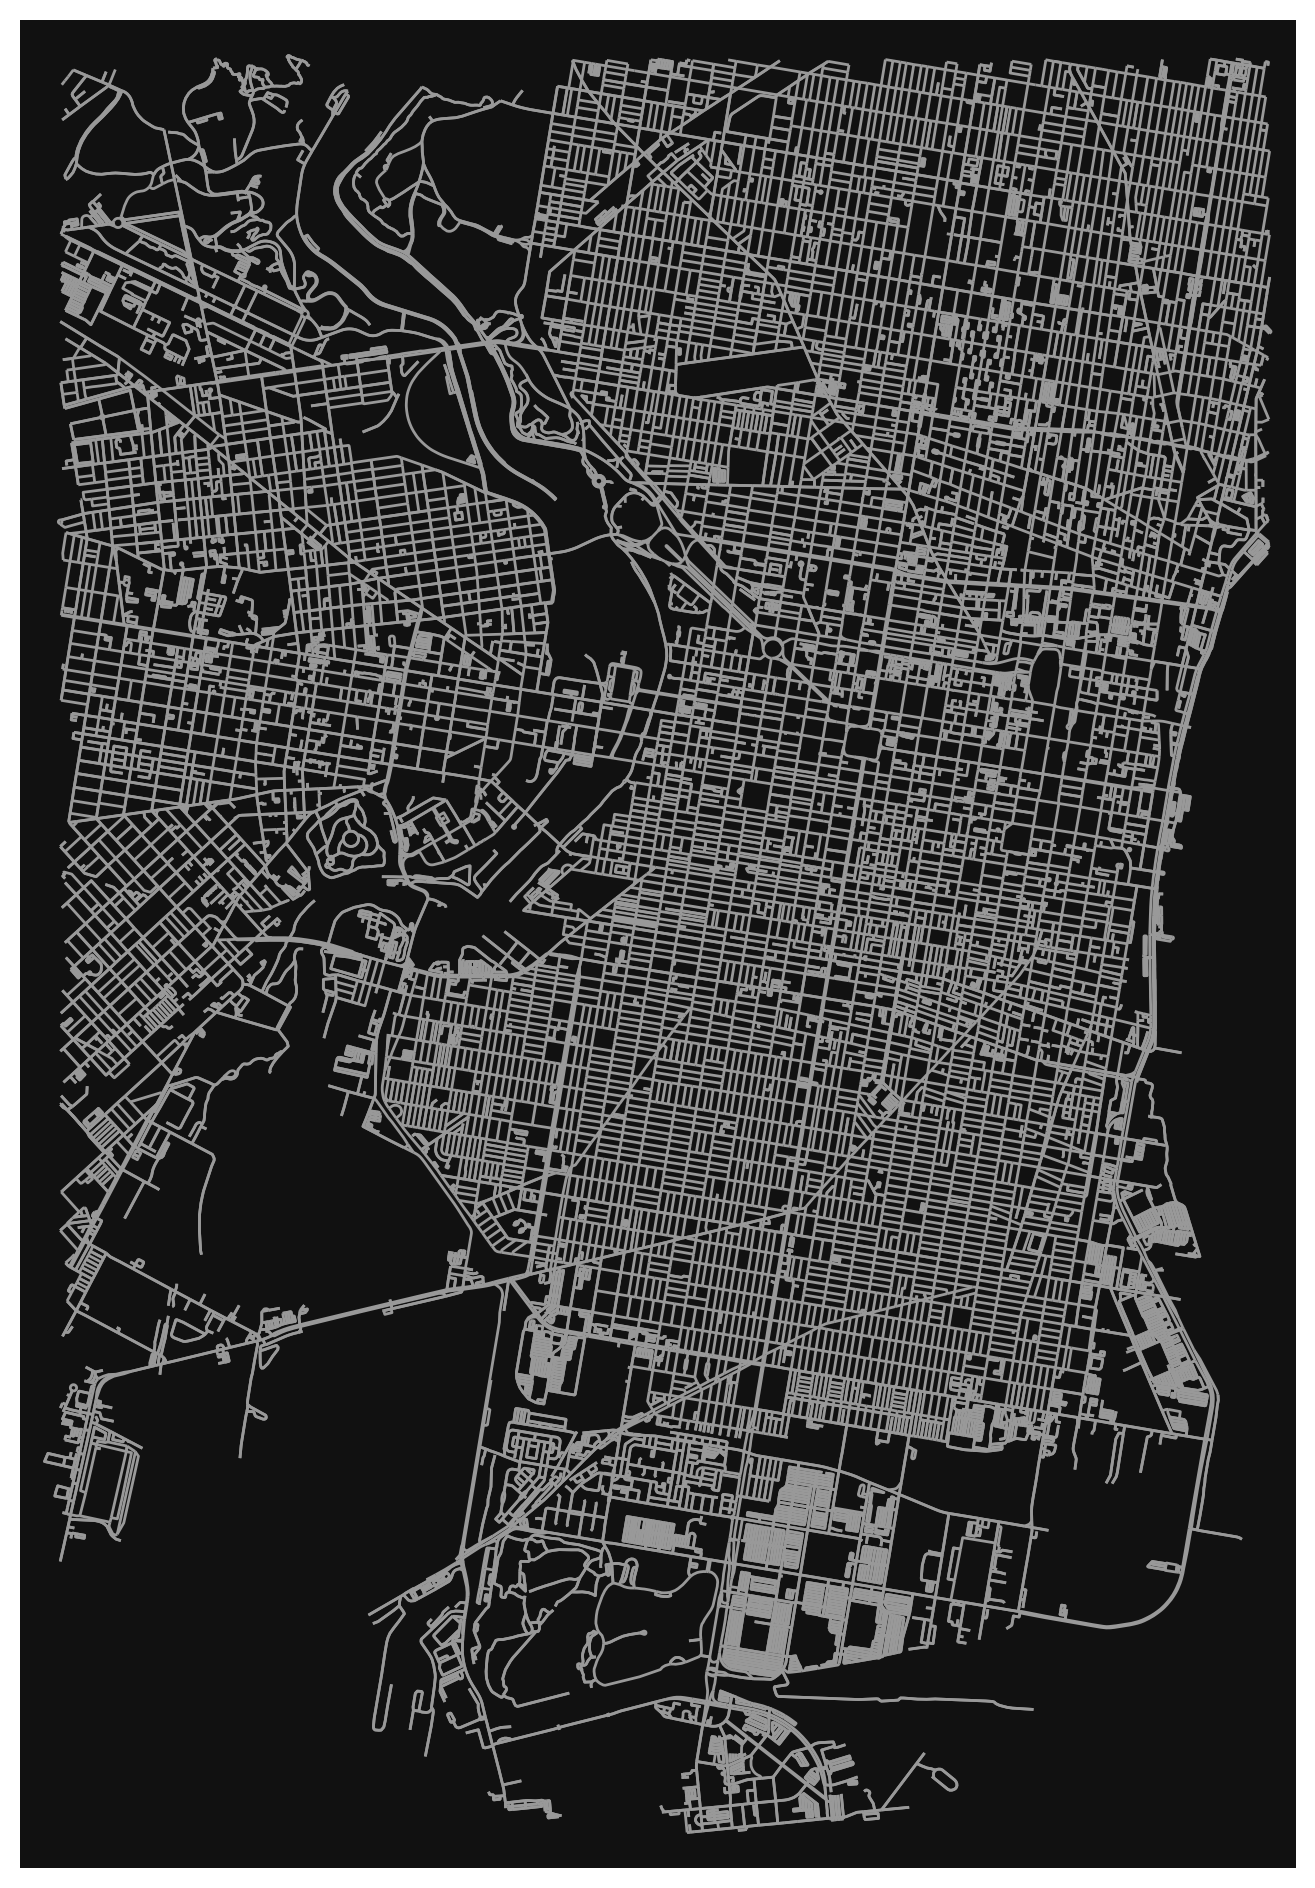

In [ ]:
ox.plot_graph(G, figsize=(12, 12), node_size=0);

Now extract the nodes (intersections) from the graph into a GeoDataFrame:

In [ ]:
intersections = ox.graph_to_gdfs(G, nodes=True, edges=False).to_crs(epsg=3857)

In [ ]:
intersections.head()

,y,x,street_count,highway,geometry
osmid,,,,,
109727072,39.920114,-75.176365,3,NaN,POINT (-8368594.627 4854340.318)
109727084,39.918876,-75.176639,3,NaN,POINT (-8368625.162 4854160.598)
109727165,39.917601,-75.176933,3,NaN,POINT (-8368657.901 4853975.496)
109727173,39.917476,-75.176959,4,NaN,POINT (-8368660.784 4853957.411)
109727183,39.917126,-75.177038,3,NaN,POINT (-8368669.590 4853906.554)


Now, compute the average distance to the 3 nearest intersections:

In [ ]:
# STEP 1: x/y coordinates of restaurants (in EPGS=3857)
intersectionsXY = get_xy_from_geometry(intersections.to_crs(epsg=3857))

# STEP 2: Initialize the algorithm
nbrs = NearestNeighbors(n_neighbors=3)

# STEP 3: Fit the algorithm on the "neighbors" dataset
nbrs.fit(intersectionsXY)

# STEP 4: Get distances for stations to neighbors
interDists, interIndices = nbrs.kneighbors(stationsXY)

# STEP 5: add back to the original dataset
bike_data['logIntersectionDists'] = np.log10(interDists.mean(axis=1))

Let's plot the stations, coloring by the new feature (distance to intersections):

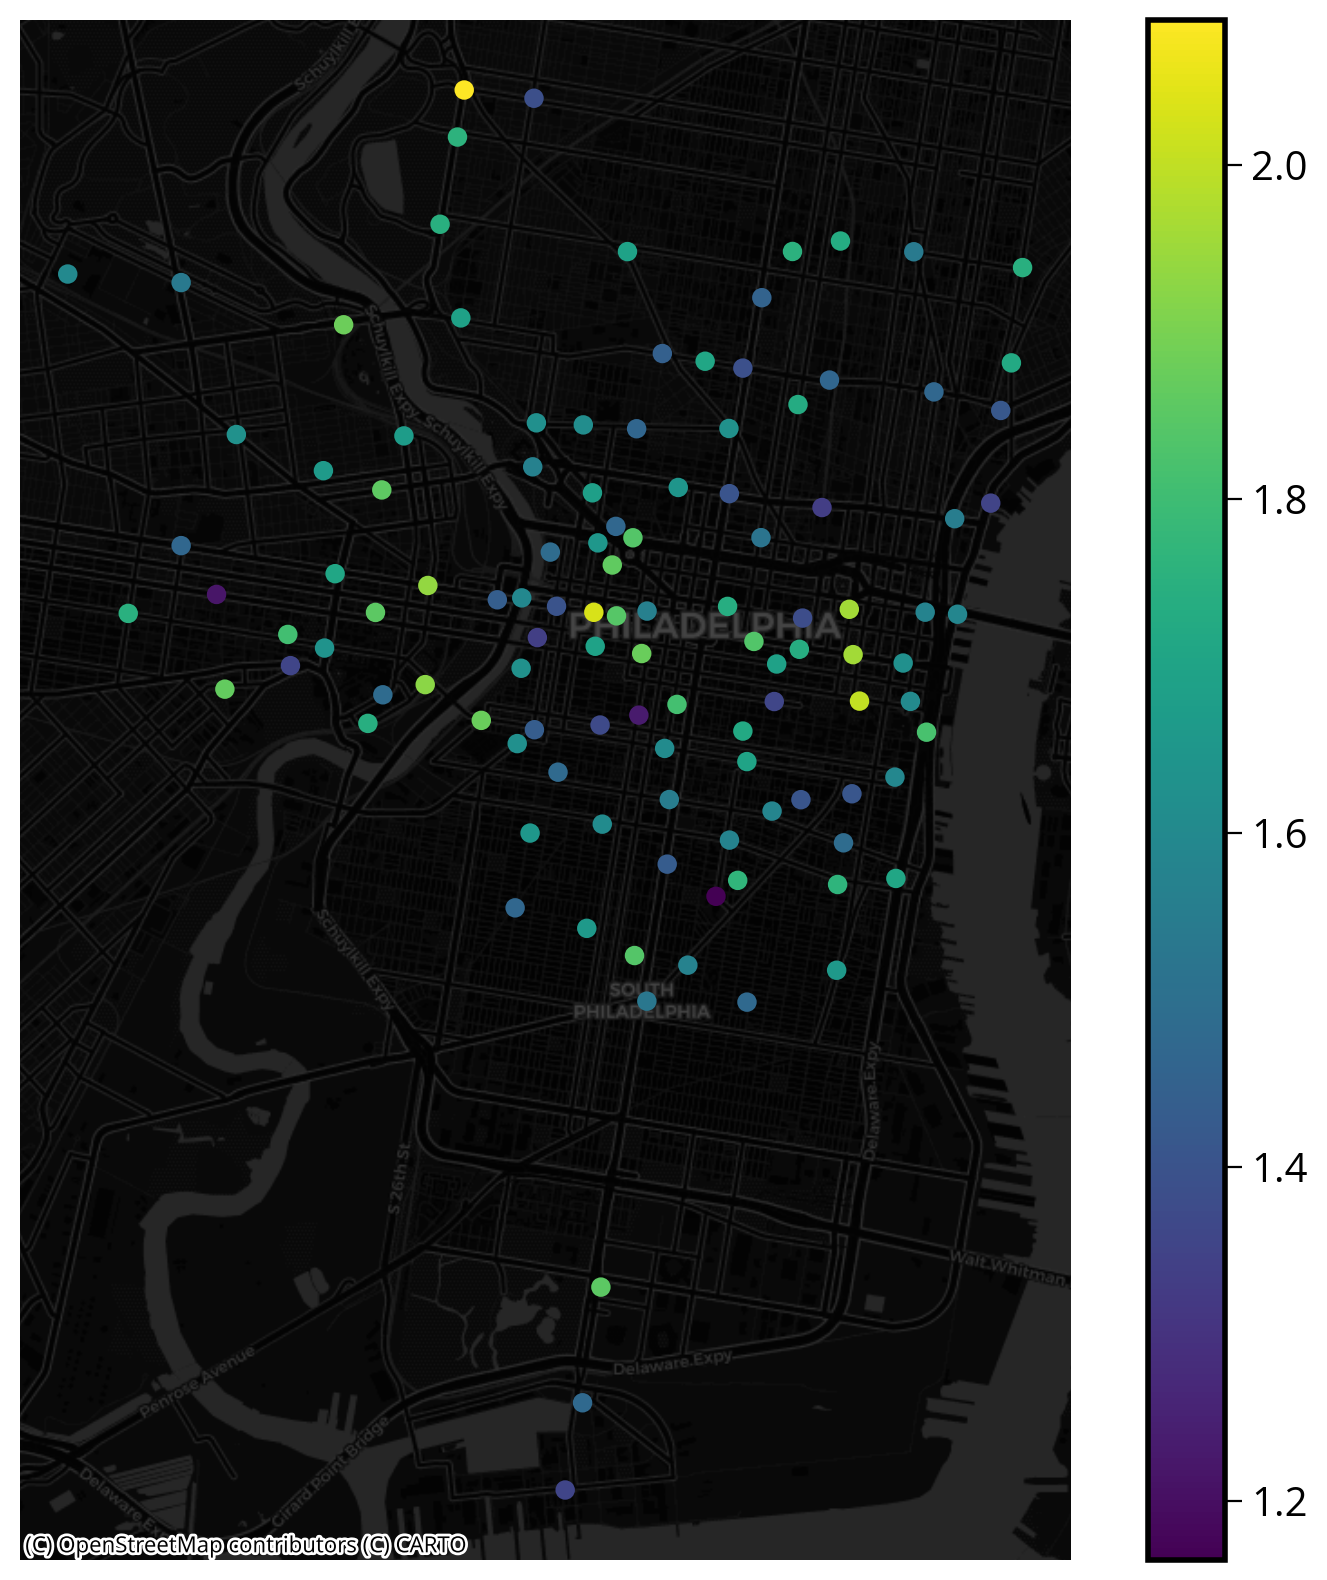

In [82]:
fig, ax = plt.subplots(figsize=(10,10))

# stations
bike_data.plot(ax=ax, column='logIntersectionDists', legend=True)

# plot the basemap underneath
ctx.add_basemap(ax=ax, crs=bike_data.crs, source=ctx.providers.CartoDB.DarkMatter)

ax.set_axis_off()

### 5. Neighboring Stations

- We need to include features that encodes the fact that demand for a specific station is likely related to the demand in neighboring stations
- This idea is known as **spatial lag**

We will add two new features:

1. The average distance to the nearest 5 stations
1. The average trip total for the nearest 5 stations

First, find the nearest 5 stations:

In [83]:
N = 5
k = N + 1
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(stationsXY)

stationDists, stationIndices = nbrs.kneighbors(stationsXY)

#### Notes

- We are matching the stations to themselves to find the nearest neighbors
- The closest match will always be the same station (distance of 0)
- So we fit for $k+1$ neighbors and will remove the closest neighbor

The log of the distances to the 5 nearest stations:

In [84]:
bike_data["logStationDists"] = np.log10(stationDists[:, 1:].mean(axis=1))

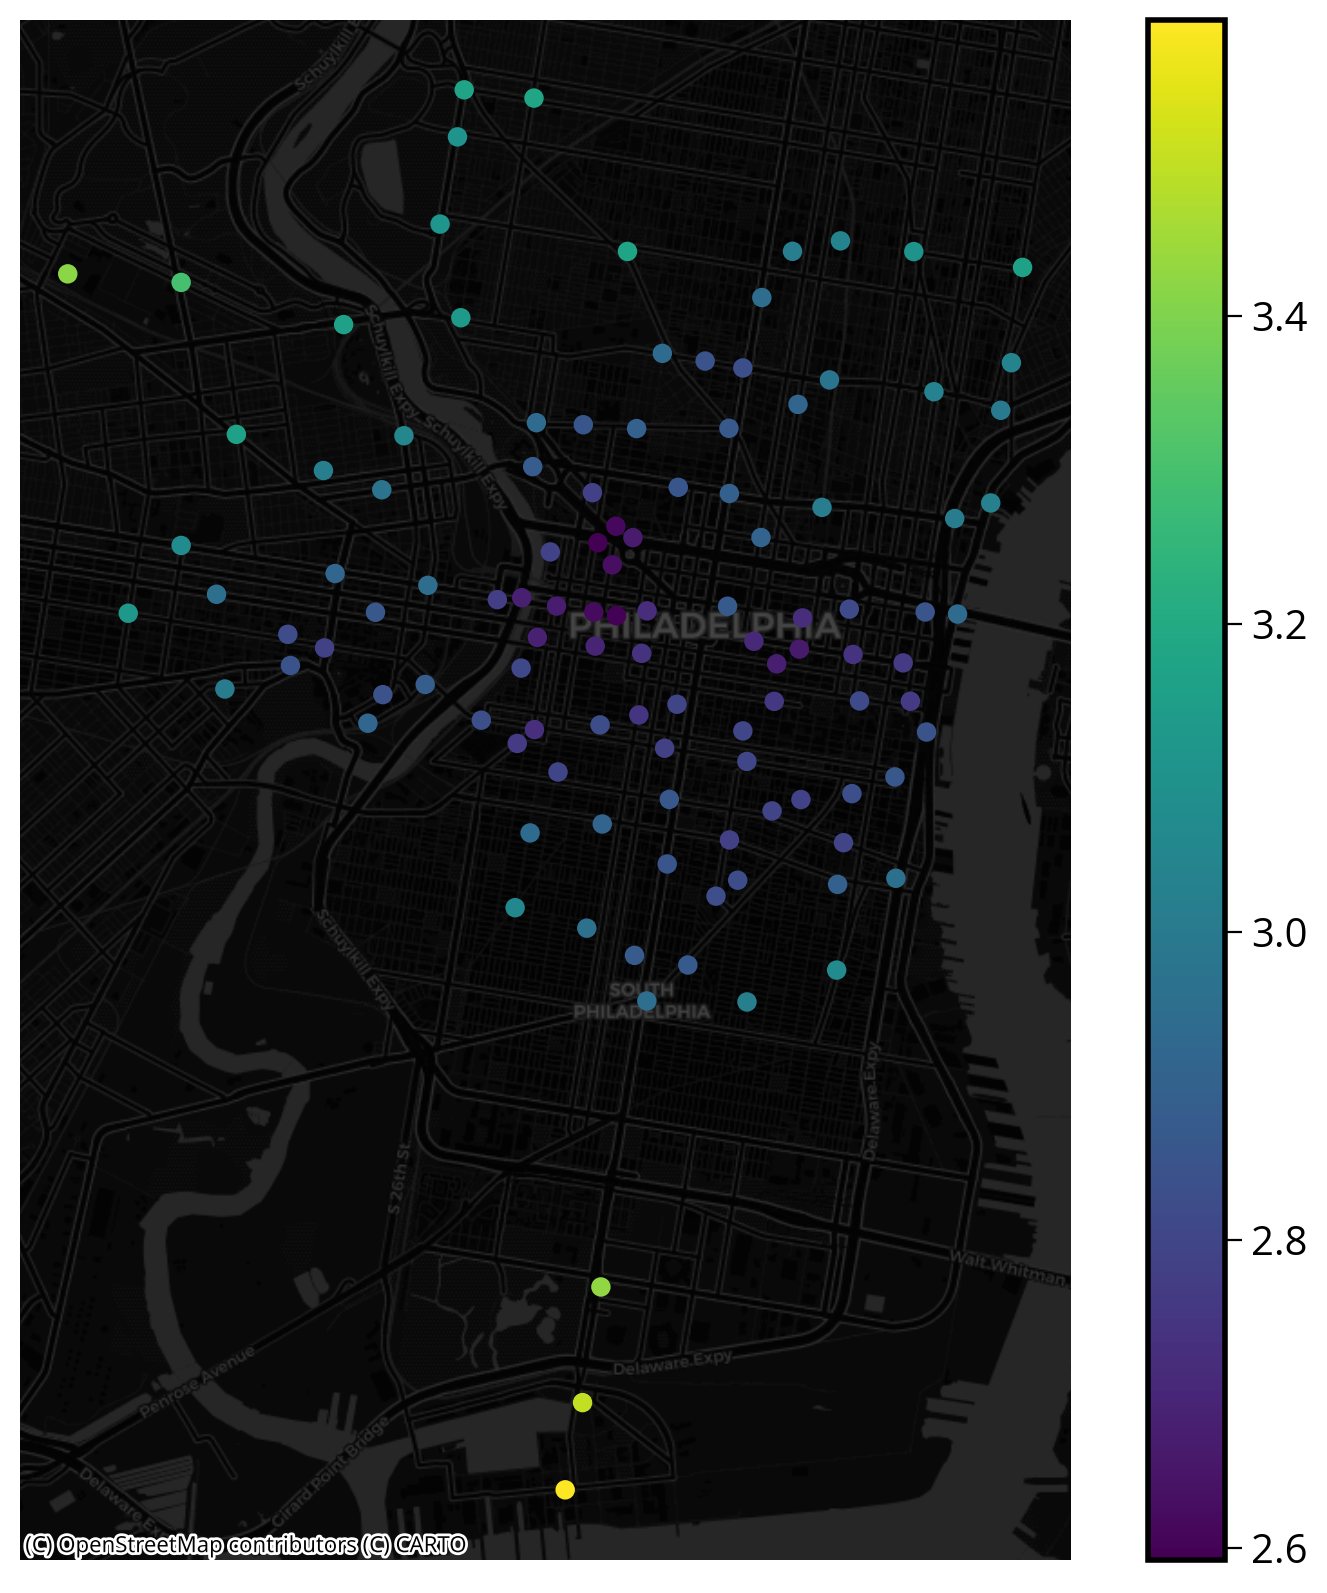

In [85]:
fig, ax = plt.subplots(figsize=(10,10))

# stations
bike_data.plot(ax=ax, column='logStationDists', legend=True)

# plot the basemap underneath
ctx.add_basemap(ax=ax, crs=bike_data.crs, source=ctx.providers.CartoDB.DarkMatter)

ax.set_axis_off()

Now, let's add the trip counts of the 5 neighboring stations:

**Use the indices returned by the NearestNeighbors() algorithm to identify which stations are the 5 neighbors in the original data**

In [86]:
stationIndices[:, 1:]

array([[ 43,  41,   1,  42,  20],
       [ 42,   0,  41,  43,  30],
       [ 97,   3, 101,  70,  18],
       [ 97,   2,  22,  35, 101],
       [ 80,  47,   7,  29,   8],
       [ 25,  12,  52,  61,  36],
       [ 22,  17, 101, 102,  14],
       [ 59,   8, 110,   4,  62],
       [ 59,   7,  73,  62,   4],
       [ 26,  28,  62,  89,  60],
       [ 51, 112,  55, 105,  49],
       [ 61,  36,  71,  37,  69],
       [  5,  77,  25,  74, 106],
       [ 42,  45,  30, 108,  41],
       [ 35,  27,  15,  22, 103],
       [ 35,  14,   3,  97,  22],
       [ 72, 110,  57, 112, 107],
       [102,  58,  56,   6, 105],
       [ 97,   2,  70,   3,  87],
       [ 65,  23,  32,  64,  73],
       [ 21,  43,   0,  66,   1],
       [ 20,  66,  24,  23,  78],
       [101,   6,   3,  35,  14],
       [ 24,  19,  80,  65,  66],
       [ 23,  21,  66,  80,  19],
       [  5,  52,  12,  36,  61],
       [ 28,   9,  27, 103,  62],
       [ 28,  26, 103,  14,   9],
       [ 26,  27,   9, 103,  62],
       [ 30,  

In [87]:
# the total trips for the stations from original data frame
total_start_trips = bike_data['total_start_trips'].values

In [88]:
total_start_trips

array([21489, 27947, 35810, 28892, 69165, 13899, 47041, 93916, 44622,
       60187, 13031,  7115, 11863, 16961, 55691,  7343, 58307, 57073,
       20127, 32433, 34331, 61592, 44565, 39669, 33963, 23814, 76540,
       27736, 29139, 40564, 37390, 45958, 37428, 28092, 39622, 41670,
       25990, 15460, 41777, 23859, 32078, 57086, 41466, 31487, 26086,
       34651, 37950, 70320, 33841, 76197, 73758, 30678, 30889, 45196,
       39962, 22193, 45734, 39869, 24477, 48285, 43113, 11012, 60386,
        8609, 37196, 27935, 31137, 14511, 21541, 26265, 26015, 31759,
       45904, 32250, 24691,  6164,  5985, 16240, 20299, 39861, 66350,
       64882, 10512,  8410, 10036, 17607,  9292, 17148,  4985, 38463,
       13656,  5106, 15065,  9527, 26922,  8486, 17799, 11669, 46670,
       23682, 25833, 33808, 39587, 48734, 25068, 27349, 15742, 64969,
       28877,  4497, 36943,  4409, 19432, 11616])

In [89]:
# get the trips for the 5 nearest neighbors (ignoring first match)
neighboring_trips = total_start_trips[stationIndices[:, 1:]]

In [90]:
neighboring_trips

array([[31487, 57086, 27947, 41466, 34331],
       [41466, 21489, 57086, 31487, 37390],
       [11669, 28892, 33808, 26015, 20127],
       [11669, 35810, 44565, 41670, 33808],
       [66350, 70320, 93916, 40564, 44622],
       [23814, 11863, 30889, 11012, 25990],
       [44565, 57073, 33808, 39587, 55691],
       [48285, 44622, 36943, 69165, 60386],
       [48285, 93916, 32250, 60386, 69165],
       [76540, 29139, 60386, 38463, 43113],
       [30678, 19432, 22193, 27349, 76197],
       [11012, 25990, 31759, 15460, 26265],
       [13899, 16240, 23814, 24691, 15742],
       [41466, 34651, 37390, 28877, 57086],
       [41670, 27736,  7343, 44565, 48734],
       [41670, 55691, 28892, 11669, 44565],
       [45904, 36943, 39869, 19432, 64969],
       [39587, 24477, 45734, 47041, 27349],
       [11669, 35810, 26015, 28892, 17148],
       [27935, 39669, 37428, 37196, 32250],
       [61592, 31487, 21489, 31137, 27947],
       [34331, 31137, 33963, 39669, 20299],
       [33808, 47041, 28892, 416

In [91]:
# Add to features
bike_data['laggedTrips'] = neighboring_trips.mean(axis=1)

#### Is there a correlation between trip counts and the spatial lag?

Yes!

We can use seaborn to make a quick plot:

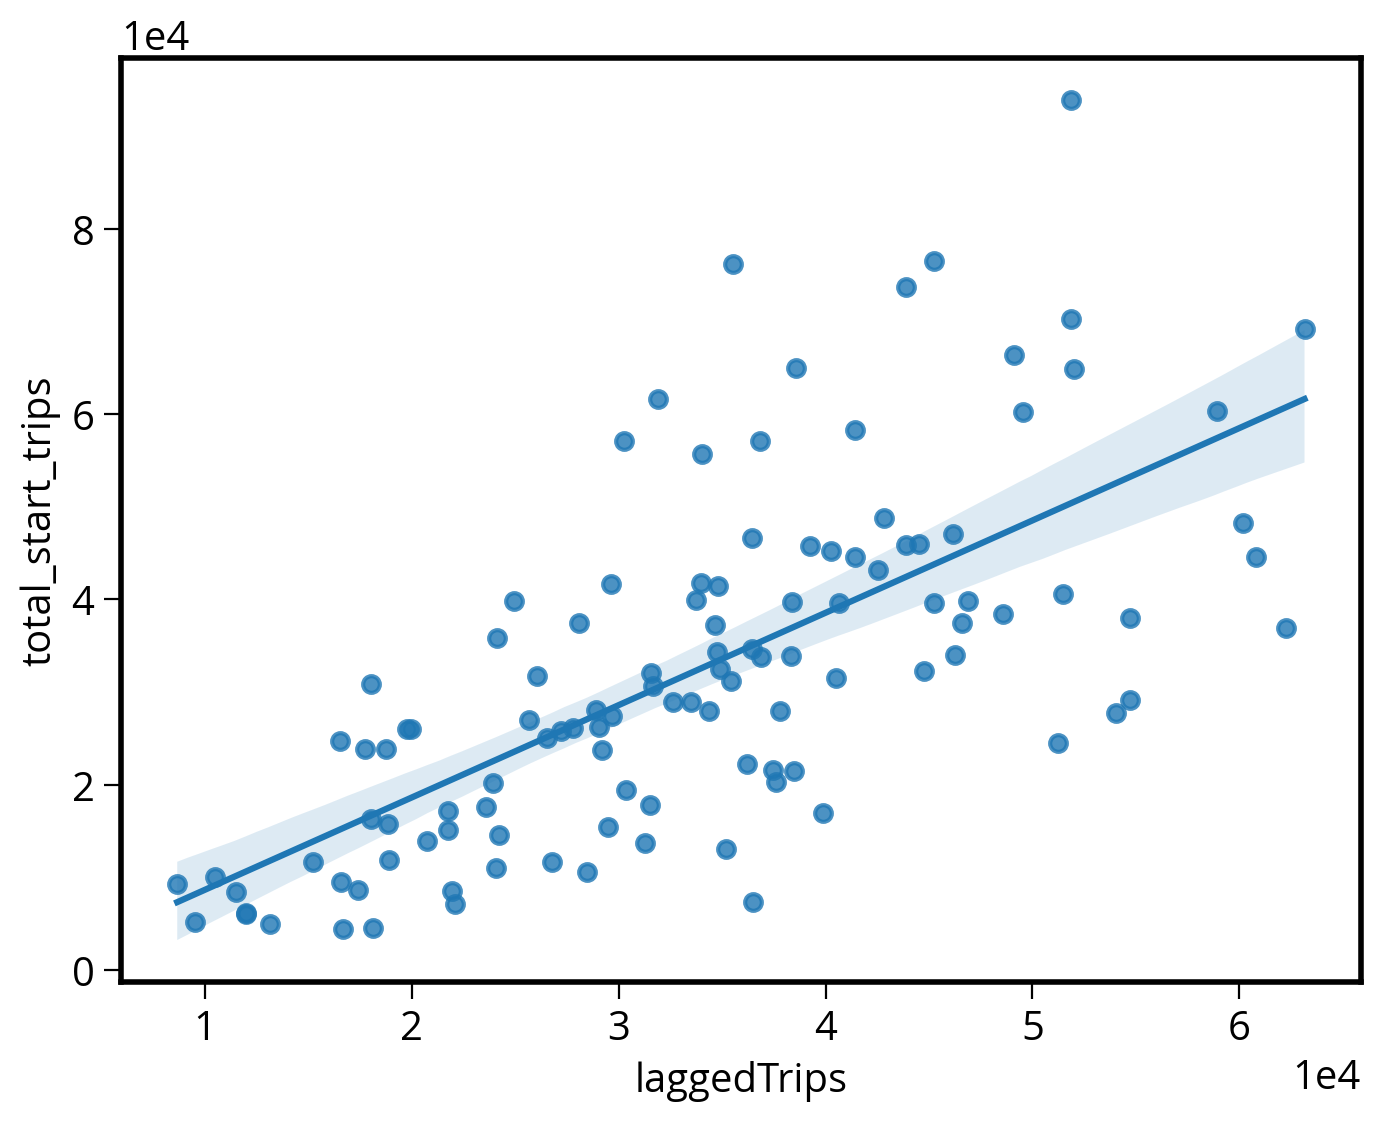

In [92]:
sns.regplot(x=bike_data['laggedTrips'], y=bike_data['total_start_trips']);

### Let's look at the correlations of all of our features

Again, use seaborn to investigate.

**Remember:** we don't want to include multipl features that are highly correlated in our model.

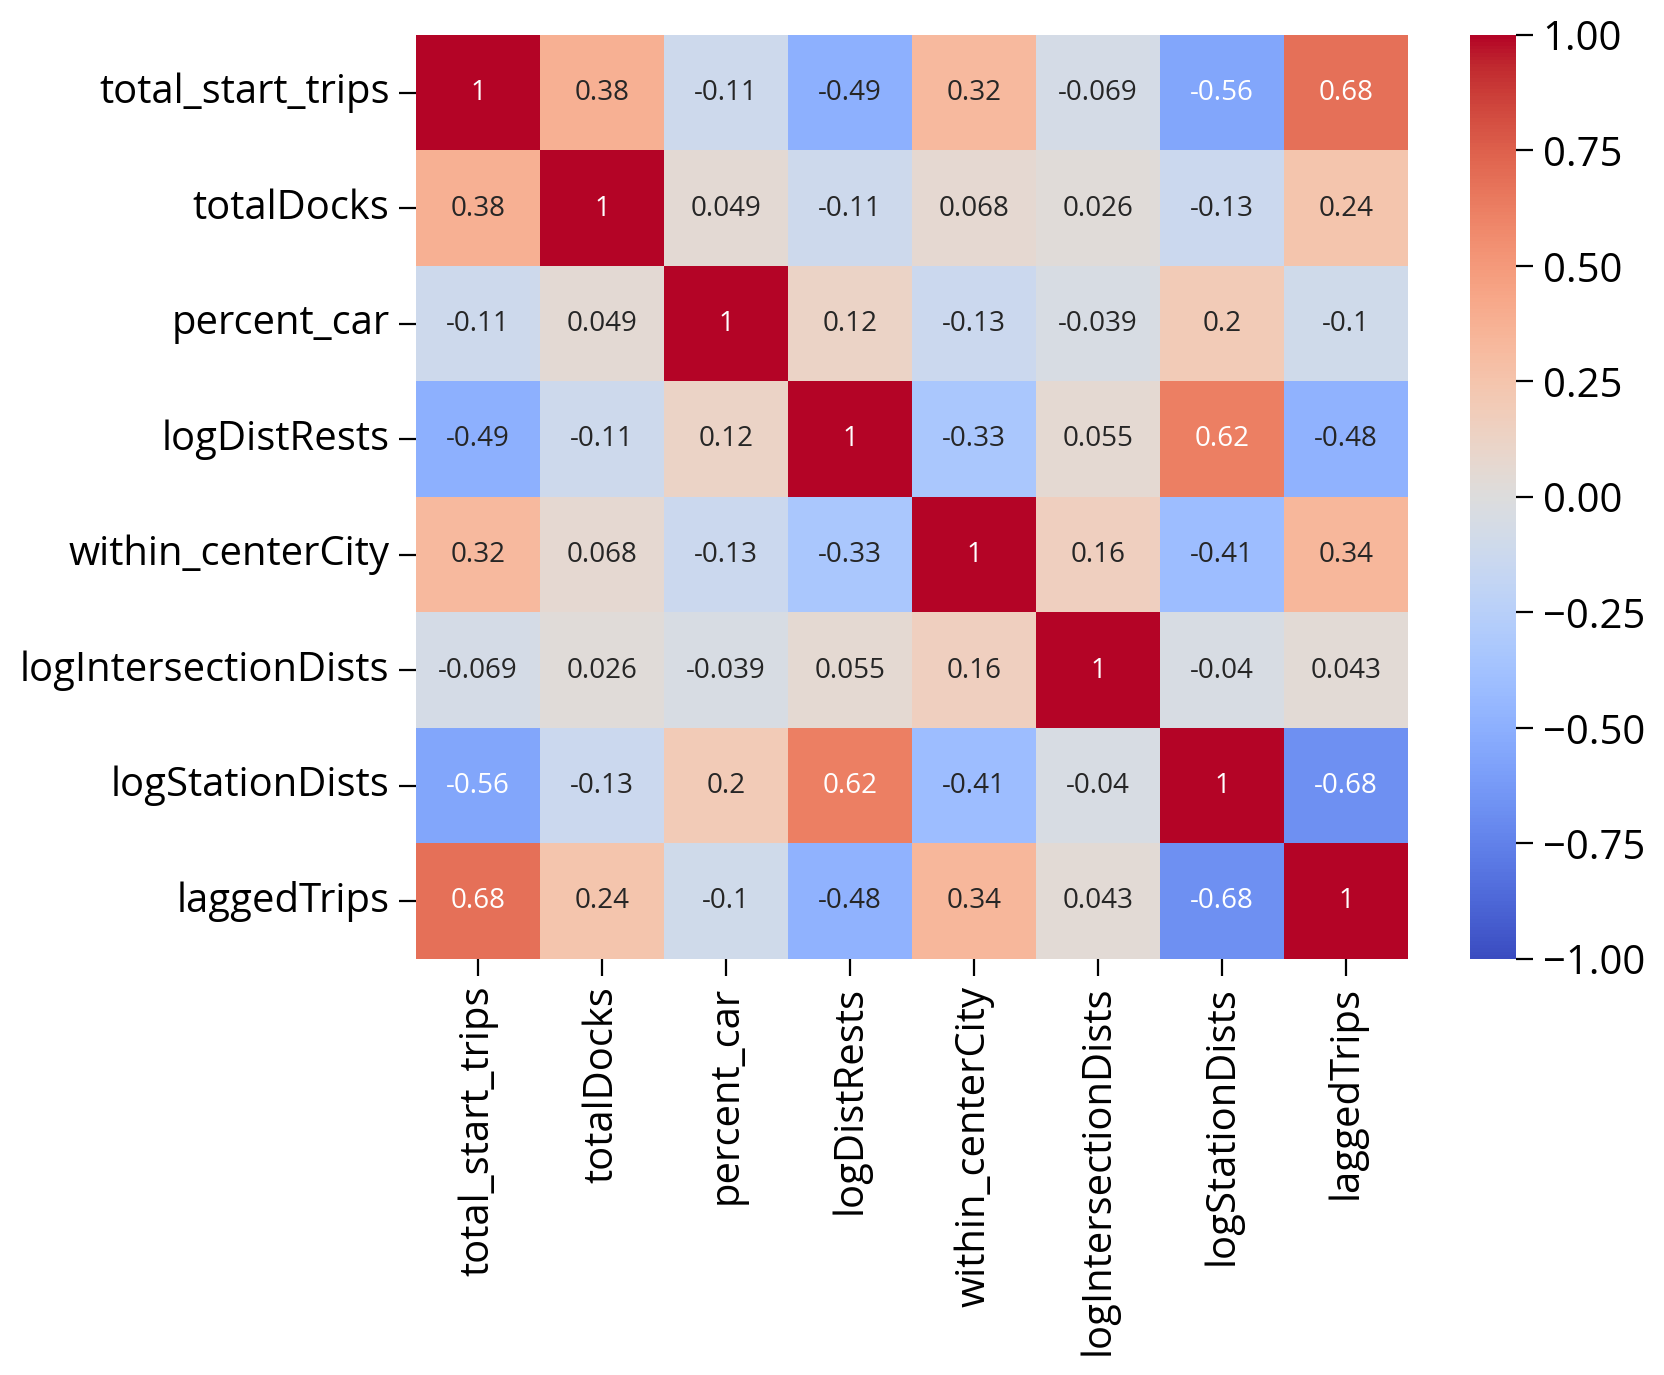

In [93]:
feature_cols = [
    "total_start_trips",
    "totalDocks",
    "percent_car",
    "logDistRests",
    "within_centerCity",
    "logIntersectionDists",
    "logStationDists",
    "laggedTrips",
]


sns.heatmap(
    bike_data[feature_cols].corr(), cmap="coolwarm", annot=True, vmin=-1, vmax=1
);

### Let's fit a model!

Just as before, the plan is to:
- Fit a random forest model, using cross validation to optimize (some) hyperparameters
- Compare to a baseline linear regression model

### Perform our test/train split

We'll use a 60%/40% split, due to the relatively small number of stations.

In [94]:
# Remove unnecessary columns
bike_features = bike_data.drop(labels=["geometry", "kioskId", "start_station"], axis=1)

In [95]:
# Split the data 
train_set, test_set = train_test_split(
    bike_features,
    test_size=0.4,
    random_state=12345
)

# the target labels: log of total start trips
y_train = np.log(train_set["total_start_trips"])
y_test = np.log(test_set["total_start_trips"])

In [96]:
# Extract out only the features we want to use
feature_cols = [
    "totalDocks",
    "percent_car",
    "logDistRests",
    "within_centerCity",
    "logIntersectionDists",
    "logStationDists",
    "laggedTrips",
]

train_set = train_set[feature_cols]
test_set = test_set[feature_cols]

### Random forest results

Let's run a simple grid search to try to optimize our hyperparameters.

In [97]:
# Setup the pipeline with a standard scaler
pipe = make_pipeline(
    StandardScaler(), RandomForestRegressor(random_state=42)
)

Try out a few different values for two of the main parameters for random forests: `n_estimators` and `max_depth`:

In [98]:
model_name = "randomforestregressor"
param_grid = {
    f"{model_name}__n_estimators": [5, 10, 25, 50, 100, 200, 300, 500],
    f"{model_name}__max_depth": [None, 2, 5, 7, 9, 13],
}

param_grid

{'randomforestregressor__n_estimators': [5, 10, 25, 50, 100, 200, 300, 500],
 'randomforestregressor__max_depth': [None, 2, 5, 7, 9, 13]}

**Important:** just like last week, we will need to prefix the parameter name with the name of the pipeline step, in this case, "randomforestregressor".

In [99]:
# Create the grid and use 10-fold CV
grid = GridSearchCV(pipe, param_grid, cv=10)

# Run the search
grid.fit(train_set, y_train);

#### Evaluate the best estimator on the test set:

In [100]:
grid.best_params_

{'randomforestregressor__max_depth': None,
 'randomforestregressor__n_estimators': 25}

In [101]:
# Evaluate the best random forest model
best_random = grid.best_estimator_
grid.score(test_set, y_test)

0.44784336111279266

#### Evaluate a linear model (baseline) on the test set

In [102]:
# Set up a linear pipeline
linear = make_pipeline(StandardScaler(), LinearRegression())

# Fit on train set
linear.fit(train_set, y_train)

# Evaluate on test set
linear.score(test_set, y_test)

0.5308339521981206

#### Only a modest improvement over the baseline model!

### Which features were the most important?

From our earlier correlation analysis, we should expect the most important features to be:
- the spatially lagged trip counts
- the distance to the nearest restaurants
- the distance to the nearest stations

In [103]:
# The best model
regressor = grid.best_estimator_["randomforestregressor"]

# Create the dataframe with importances
importance = pd.DataFrame(
    {"Feature": train_set.columns, "Importance": regressor.feature_importances_}
)

# Sort importance in descending order and get the top
importance = importance.sort_values("Importance", ascending=False)

# Plot
importance.hvplot.barh(x="Feature", y="Importance", flip_yaxis=True, height=300)

:Bars   [Feature]   (Importance)

In [104]:
importance

,Feature,Importance
2,logDistRests,0.469234
6,laggedTrips,0.260854
5,logStationDists,0.151690
1,percent_car,0.059918
0,totalDocks,0.035346
4,logIntersectionDists,0.022430
3,within_centerCity,0.000528


### Let's analyze the spatial structure of the predictions visually

We'll plot the predicted and actual trip values

Use the test set index (`test_set.index`) to get the data from the original data frame (`bike_data`).

This will ensure we will have `geometry` info (not used in the modeling) for our test data set:

In [105]:
test_set.index

Int64Index([ 16,  37,   2,  33,  30,  38,  39,  89,  75,  13,  95,  65,  31,
             77,  73,   6,  41,  92,  74, 113,  35,  76,  79,  11,  25, 106,
             69,  17,  21,  47,  55,  56,  54,  52, 101,  44,  67,  88,  60,
              1,   4,  81,  85,  24,  27,  40],
           dtype='int64')

In [106]:
# Extract the test data from the original dataset
# This will include the geometry data
X = bike_data.loc[test_set.index]

In [107]:
# test data extracted from our original data frame
X.head()

,geometry,kioskId,start_station,total_start_trips,totalDocks,percent_car,logDistRests,within_centerCity,logIntersectionDists,logStationDists,laggedTrips
16,POINT (-8366906.511 4856826.354),3025,3025,32433,15,0.274621,2.462636,0,1.575381,2.786846,34895.6
37,POINT (-8366433.404 4858289.916),3052,3052,70320,25,0.436047,2.552139,1,1.358118,2.753161,51885.4
2,POINT (-8366765.136 4857977.729),3007,3007,69165,20,0.188889,2.586702,0,1.719883,2.802207,63154.4
33,POINT (-8365600.734 4858785.078),3047,3047,41466,20,0.392508,2.563806,0,1.957440,2.739015,34807.0
30,POINT (-8364041.148 4861364.388),3041,3041,23859,26,0.706773,2.265590,0,1.415532,3.000100,17758.2


In [108]:
test_set.head()

,totalDocks,percent_car,logDistRests,within_centerCity,logIntersectionDists,logStationDists,laggedTrips
16,15,0.274621,2.462636,0,1.575381,2.786846,34895.6
37,25,0.436047,2.552139,1,1.358118,2.753161,51885.4
2,20,0.188889,2.586702,0,1.719883,2.802207,63154.4
33,20,0.392508,2.563806,0,1.957440,2.739015,34807.0
30,26,0.706773,2.265590,0,1.415532,3.000100,17758.2


 #### The data frame indices lines up!

Now, make our predictions, and convert them from log to raw counts:

In [109]:
# Predictions for log of total trip counts
log_predictions = grid.best_estimator_.predict(test_set)

# Convert the predicted test values from log
X['prediction'] = np.exp(log_predictions)

Let's make the plot with side-by-side panels for actual and predicted:

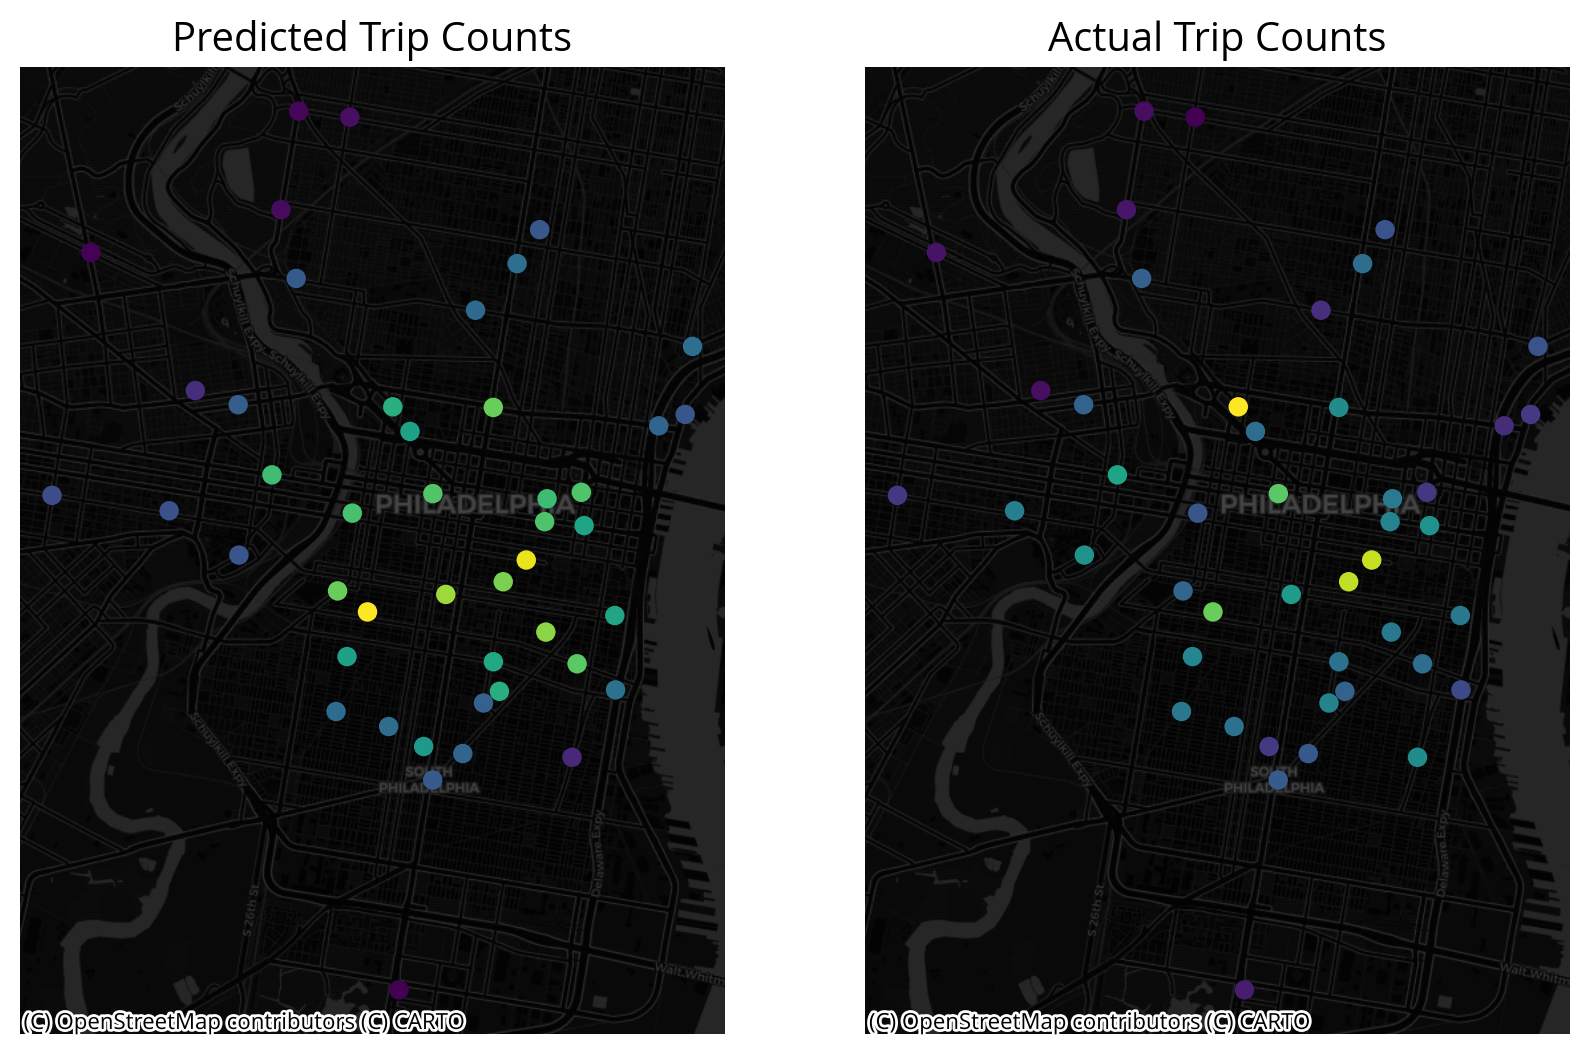

In [110]:
# Plot two columns
fig, axs = plt.subplots(ncols=2, figsize=(10,10))

# Predicted values
X.plot(ax=axs[0], column='prediction')
ctx.add_basemap(ax=axs[0], crs=X.crs, source=ctx.providers.CartoDB.DarkMatter)
axs[0].set_title("Predicted Trip Counts")

# Actual values
X.plot(ax=axs[1], column='total_start_trips')
ctx.add_basemap(ax=axs[1], crs=X.crs, source=ctx.providers.CartoDB.DarkMatter)
axs[1].set_title("Actual Trip Counts")


axs[0].set_axis_off()
axs[1].set_axis_off()

### The results are... not great

#### The good
We are capturing the general trend of within Center City vs. outside Center City

#### The bad
The values of the trip counts for those stations within Center City do not seem to be well-represented

### Can we improve the model?

Yes! 

This is a classic example of underfitting, for a few reasons:

- The analysis only used seven features. We should be able to improve the fit by adding more features, particularly features that capture information of the stations within Center City (where the model seems to be struggling).
- The correlation analysis did not indicate much correlation between features, and the features all had a pretty large correlation with the total trip counts. So, in some sense, the features all seem to be important, and we just need to add more.

### Features to investigate:

- Additional census demographic data: 
    - e.g., population, income, percent with bachelor's degree or higher
- Amenities / disamenities
    - Lots of options from OpenDataPhilly and OpenStreetMap
    - Criminal incidents, distance to parks, restaurants, new construction permits, etc.
- Transportation network
    - Distance to the nearest bus station is a good place to start (see [https://wiki.openstreetmap.org/wiki/Map_Features](https://wiki.openstreetmap.org/wiki/Map_Features) for the amenity tag)
- Changing *k* values for distance-based features
    - Experiment with different values of *k* to see if they improve the model

### Other options for bikeshare data

When trying to improve the accuracy of the model, another option is incorporating additional data. In this case, we can look to other cities and include trip data for these cities. Some good places to start:

- [Boston](https://www.bluebikes.com/system-data)
- [Chicago](https://www.divvybikes.com/system-data)
- [Washington D.C](https://www.capitalbikeshare.com/system-data)


## That's it!